In [1]:
import warnings
# warnings.filterwarnings('ignore')
import torch
import numpy as np
import matplotlib.pyplot as plt
import copy
import os
import json
import pandas as pd
import arviz as az
from arviz.utils import get_coords, _var_names

from flonacomldft.utils.io_utils import (
    load_csv_file,
    load_pickle_file,
)

from flonacomldft.utils.diagnostics import R_hat

from flonacomldft.free_energy_computations import (
    compute_BAR_from_samples, compute_TFP_from_samples
)
from ase.units import kB

beta = 1.0 / (kB * 350)
mode_labels = [0, 1]

In [13]:
def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

### 0.1 - Dataframe with all the args of the simulations

In [2]:
# MARYLOU
project_path = '/Users/marylou/Dropbox/Prof/Experiments/_ceph/ml-dft'
subproject_path = project_path + '/adaptive-350/20231911_adaptive_single_isomer/'

os.listdir(subproject_path)

dic_args = {}

In [3]:
##### MD simulations
isomers = [0]*4 + [1]*4
flows_ids = [int('3006479{:d}'.format(i)) for i in range(8)]
samples_ids = [int('3006662{:d}'.format(i)) for i in range(8)]

subsubproject_path = subproject_path + '3-flows-md/'

df_args = pd.DataFrame()
for isomer_id, number_id in zip(isomers, flows_ids):
    args_file = 'args_train_flow_model_{:d}.json'.format(number_id)
    f = open(subsubproject_path+args_file)
    data = json.load(f)
    sub_df = pd.DataFrame(data, index=[0])
    df_args = df_args.append(sub_df)

dic_args['MD-training'] = df_args

df_args = pd.DataFrame()
for isomer_id, number_id in zip(isomers, samples_ids):
    args_file = 'args_samples_from_flow_{:d}.json'.format(number_id)
    f = open(subsubproject_path+args_file)
    data = json.load(f)
    sub_df = pd.DataFrame(data, index=[0])
    df_args = df_args.append(sub_df)

dic_args['MD-sampling'] = df_args


/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_36389/3194167661.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_df)
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_36389/3194167661.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_df)
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_36389/3194167661.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_df)
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_36389/3194167661.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_

### 0.2 - Loading models

In [4]:
def load_models(isomer_id, process_id, project_path=subproject_path+ '/1-adaptive/'):
    if '3-flows-md' in project_path:
        f = 'is{:d}_flow_dic_{:d}.pkl'.format(isomer_id, process_id)
        models = [load_pickle_file(f, path=project_path)['model']]
    else:
        f = 'adaptive_sampling_is{:d}_{:d}.pkl'.format(isomer_id, process_id)
        dic_trainings = load_pickle_file(f, path=project_path)
        models = [ dic[0]['model'] for dic in dic_trainings['dict_flows'] ]
    return models

In [5]:
def load_mlp_models(isomer_id, process_id, project_path=subproject_path+ '/1-adaptive/'):
    f = 'adaptive_sampling_is{:d}_{:d}.pkl'.format(isomer_id, process_id)
    dic_trainings = load_pickle_file(f, path=project_path)
    mlp_models = [dic[0]['model']  for dic in dic_trainings['dict_mlps']]
    
    return mlp_models

### 0.3 - Loading the data

In [6]:
kinds = ['xs_adaptive', 'xs_proposals', 'MD-sampling']

# def load_samples_n_energies(kind, isomer_id, process_id, project_path=subproject_path + '/1-adaptive/'):
#     torch_tensor = load_csv_file('{:s}_is{:d}_{:d}.csv'.format(kind, isomer_id, process_id),
#                   path=project_path)
#     return torch_tensor[:, :12], torch_tensor[:, 12]

def load_samples_n_energies(kind, isomer_id, process_id, project_path=subproject_path + '/1-adaptive/'):
    if kind == 'xs_adaptive':
        torch_tensor = load_csv_file('{:s}_is{:d}_{:d}.csv'.format(kind, isomer_id, process_id),
                    path=project_path)
        xs = torch_tensor[:, :12]
        us = torch_tensor[:, 12]
    elif kind == 'MD-sampling':
        torch_tensor = load_csv_file('is{:d}_samples_rc_md_{:d}.csv'.format(isomer_id, process_id),
                    path=project_path)
        xs = torch_tensor[:, :12]
        us = torch_tensor[:, 12]
    elif kind == 'xs_proposals':
        # f = 'adaptive_sampling_is{:d}_{:d}.pkl'.format(isomer_id, process_id)
        # dic_trainings = load_pickle_file(f, path=project_path)
        # xs = torch.stack(dic_trainings['xs_proposals']).reshape(-1, 12)
        # us = torch.stack(dic_trainings['us_proposals']).reshape(-1)
        torch_tensor = load_csv_file('is{:d}_proposals_xs_{:d}.csv'.format(isomer_id, process_id),
                    path=project_path)
        xs = torch_tensor[:, :12]
        us = torch_tensor[:, 12]

    return xs, us

In [7]:
"""
Script with Metropolis-Hasting algorithm. 

"""

import time
import numpy as np
import torch
import tqdm

from flonacomldft.collective_variables import get_collective_variables
# from ase.parallel import parprint as print
from ase.units import kB

#TODO: Add calculator for MLP
#TODO: Add cv values to return
#TODO: add docstrings

def run_metropolis(model, 
                    init, 
                    n_chains,
                    n_steps,
                    energy_type,
                    temperature,
                    mixture,
                    mlp_models=None,
                    frac_computed=0.2,
                    dim=12,
                    update_weights=True,
                    scheduler_weights=10,
                    alpha=0.5,
                    return_ratios=True,
                    return_proposals=True,
                    with_tqdm=False,
                    device='cpu',
                    folder_name=None,
                 ):

    assert init.shape[0] == n_chains

    if mixture:
        try:
            assert len(model.models) > 1
        except:
            raise RuntimeError("Model is not a mixture")
    
    print("Running Metropolis-Hastings")

    x_init = init[:, :dim]
    u_init = init[:, dim]
    isomer_init = init[:, dim+1]

    beta = 1 / (kB * temperature)

    print("Number of chains: {:d}".format(n_chains))
    print("Number of steps: {:d}".format(n_steps))
    print("Temperature: {:.1f}K".format(temperature))
    print("Energy Type: {:s}".format(energy_type))

    if "mlp" in energy_type:
        #TODO: Add calculator for MLP
        
        if (mlp_models is None):
            raise RuntimeError("No model to calculate energy")
        
        if mixture:
            print('Mixture model')
            model_mlp_is0, model_mlp_is1 = mlp_models
        else:
            if(isomer_init.sum()==0):
                model_mlp_is0 = mlp_models[0]
            else:
                model_mlp_is1 = mlp_models[0]
        
        print("Use Neural Predictor: True")
    
    else:
        
        print("No Neural Predictor")

    use_calc = False

    if return_ratios:
        ratios = []

    if return_proposals:
        xs_proposals = []
        us_proposals = []
        isomers_proposals = []
        nlls_proposals = []

    print("Mixture Model: {:s}".format(str(mixture)))

    if mixture:
        weights = [model.weights.clone().detach()]

    xs = []
    us = []
    accs = []
    isomers = []
    nlls = []

    time_step_mcmc = []

    if with_tqdm:
        pbar = tqdm.tqdm(range(n_steps))
    else:
        pbar = range(n_steps)
        print("Step \t Acc Rate")

    for dt in pbar:

        if mixture:
            x_new, isomer_new = model.sample(n_chains, return_mus=True)
        else:
            x_new = model.sample(n_chains)
            isomer_new = isomer_init.clone()

        x_new = x_new.clone().detach() #set float
        isomer_new = isomer_new.clone().detach() #set dype
        
        nll_x = model.nll(x_new)
        nll_x_init = model.nll(x_init)

        if return_proposals:
            xs_proposals.append(x_new.clone().detach())
            isomers_proposals.append(isomer_new.clone().detach())
            nlls_proposals.append(nll_x.clone().detach())

        if "mlp" in energy_type:

            u_new = torch.zeros((n_chains, 1)).squeeze()

            if mixture:
                u_new[~isomer_new.bool()] = model_mlp_is0(x_new[~isomer_new.bool()]).reshape(1, -1)
                u_new[isomer_new.bool()] = model_mlp_is1(x_new[isomer_new.bool()]).reshape(1, -1)

            else:
                if(isomer_new.sum()==0):
                    u_new = model_mlp_is0(x_new)
                else:
                    u_new = model_mlp_is1(x_new)

            u_new = u_new.squeeze()

        time_step_mcmc.append(time.time())

        if return_proposals:
            us_proposals.append(u_new.clone().detach())
        
        ratio = -beta * u_new + nll_x
        ratio += beta * u_init - nll_x_init
        ratio = torch.exp(ratio)

        if return_ratios:
            ratios.append( torch.min(ratio.clone().detach(), 
                            torch.ones_like(ratio)) )

        s = torch.rand_like(ratio)
        acc = s < torch.min(ratio.detach(), torch.ones_like(ratio))

        x_new[~acc] = x_init[~acc]
        u_new[~acc] = u_init[~acc]

        if mixture:
            isomer_new[~acc] = isomer_init[~acc]
        
        else:
            isomer_new = isomer_init.clone()
        
        xs.append(x_new.clone().detach())
        us.append(u_new.clone().detach())
        accs.append(acc.clone().detach())
        isomers.append(isomer_new.clone().detach())
        nlls.append(model.nll(x_new).clone().detach())

        x_init = x_new.clone().detach()
        u_init = u_new.clone().detach()
        isomer_init = isomer_new.clone().detach()

        if with_tqdm:
            pbar.set_description("Step {:d} \t Acceptance Rate {:.3f}".format(
                dt, acc.float().mean().item()))
        else:
            print("{:d} \t {:.3f}".format( dt, 
                                        acc.float().mean().item()
                                        )
            )

        if mixture and update_weights and dt > 0 and dt % scheduler_weights == 0:

            window_weights = torch.stack( [(~torch.stack(isomers).bool())[-scheduler_weights:].float().mean(),
                              torch.stack(isomers)[-scheduler_weights:].float().mean()] )

            new_weights = alpha * model.weights.clone() + (1 - alpha) * window_weights.clone()

            if torch.all(new_weights < 0.75):

                model.weights = new_weights.clone()

            weights.append(model.weights.clone().detach())

    to_return = {
        'xs': torch.stack(xs),
        'us': torch.stack(us),
        'accs': torch.stack(accs),
        'isomers': torch.stack(isomers),
        'nlls': torch.stack(nlls),
        'time_mcmc': time_step_mcmc,
    }

    if return_ratios:
        to_return['ratios'] = torch.stack(ratios)

    if return_proposals:
        to_return['xs_proposals'] = torch.stack(xs_proposals)
        to_return['us_proposals'] = torch.stack(us_proposals)
        to_return['isomers_proposals'] = torch.stack(isomers_proposals)
        to_return['nlls_proposals'] = torch.stack(nlls_proposals)

    if use_calc:
            
        to_return['xs_calc'] = torch.stack(xs_calc)
        to_return['us_calc'] = torch.stack(us_calc)
        to_return['isomers_calc'] = torch.stack(isomers_calc)
        to_return['inds_calc'] = torch.stack(inds_calc)

    if mixture and update_weights:
        to_return['weights'] = torch.stack(weights)

    return to_return


### 0.z - Inspecting the models

#### 0.z.3 - MD only

/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


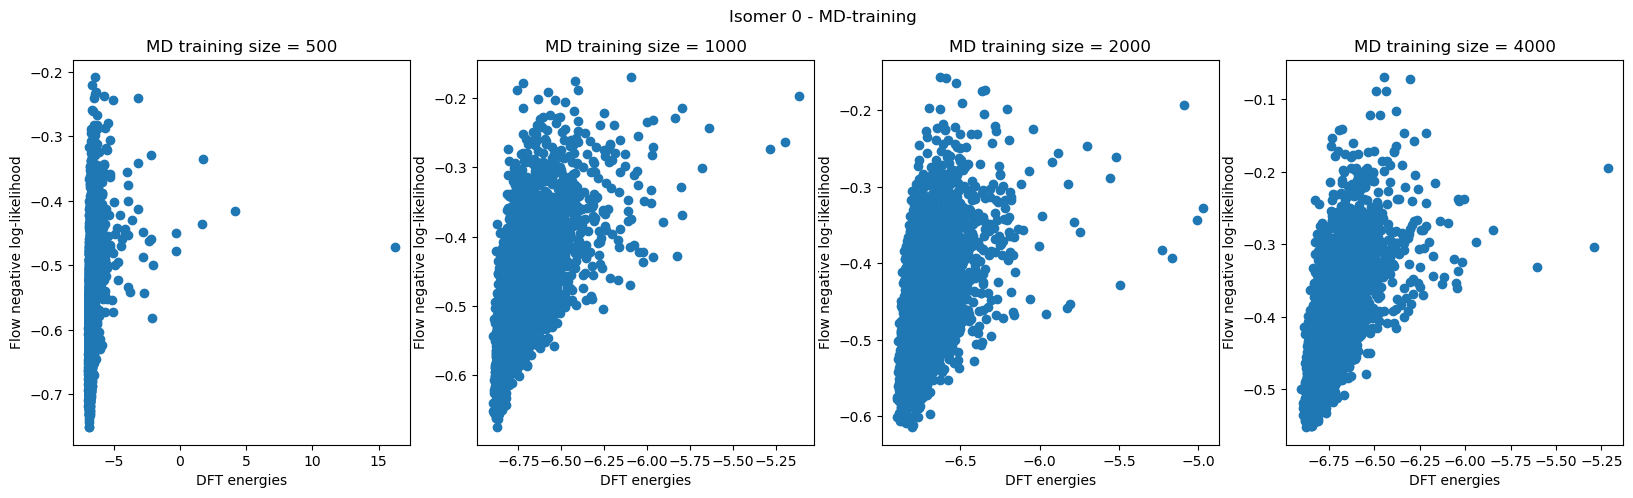

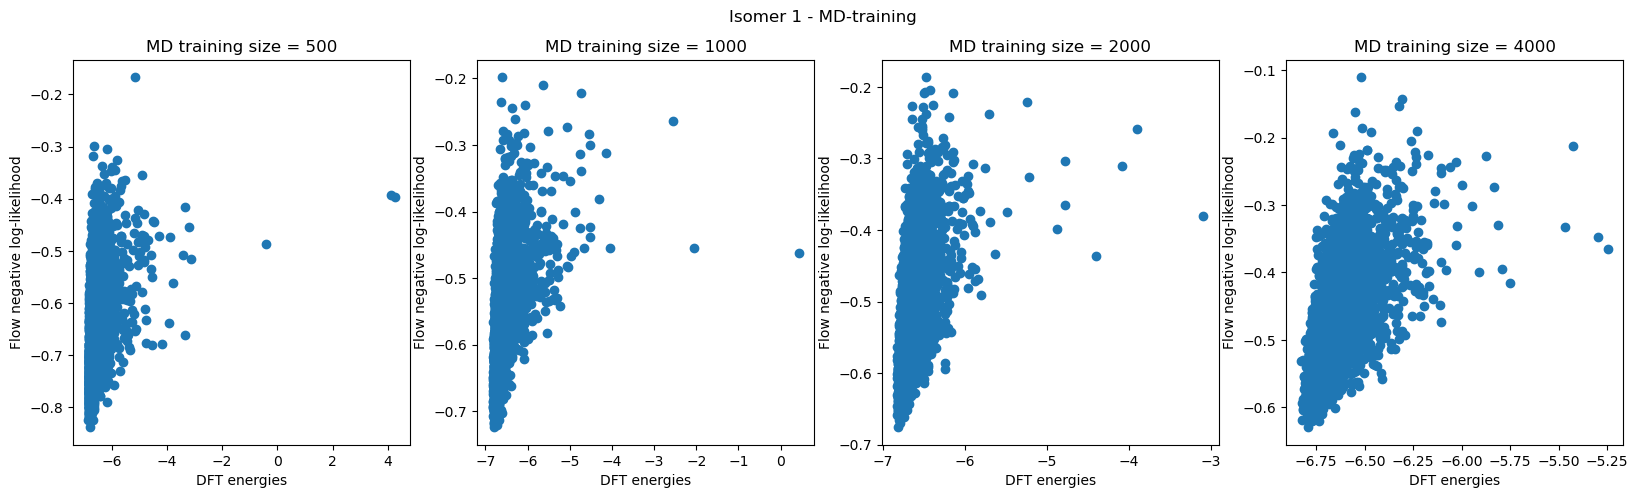

In [8]:
kind = 'MD-training'
df_args = dic_args[kind]

df_args_sample = dic_args['MD-sampling']

for isomer_id in mode_labels:
    df_isomer = df_args.loc[(df_args['isomer_label'] == isomer_id)]
    df_isomer_sample = df_args_sample.loc[(df_args_sample['isomer_label'] == isomer_id)]
    
    md_training_sizes = df_isomer['N'].values
    process_ids = df_isomer['process_id'].values
    samples_ids = df_isomer_sample['process_id'].values

    plt.figure(figsize=(5 * 4 / 1, 5 * 1))
    plt.suptitle('Isomer {:d} - {:s}'.format(isomer_id, kind))
    axs = [plt.subplot(1, int(4 // 1), i+1) for i in range(4)]
    ax_ = 0

    for md_training_size, process_id, samples_id in zip(md_training_sizes, process_ids, samples_ids):

        models = load_models(isomer_id, process_id, project_path=subproject_path + '/3-flows-md/') 

        prop_samples, energy_target = load_samples_n_energies('MD-sampling', isomer_id, samples_id, project_path=subproject_path + '/3-flows-md/')
        # mc_samples, mc_energy_target = load_samples_n_energies('xs_adaptive', isomer_id, process_id, project_path=subproject_path + '/2-adaptive-mlp/')
            
        logprob_prop = (- models[0].nll(prop_samples)).detach().numpy()
        logprob_target = (- beta * energy_target).detach().numpy()
    
        plt.sca(axs[ax_])
        plt.scatter( - logprob_target / beta, - logprob_prop / beta)
        plt.xlabel('DFT energies')
        plt.ylabel('Flow negative log-likelihood')
        plt.title('MD training size = {:d}'.format(md_training_size))

        ax_ += 1

### Reconstructing the training/test datasets

In [9]:
path_datasets = subproject_path + 'database/andersen/datasets'
md_training_sizes = [500, 1000, 2000, 4000]

dim = 12

dic_md_training_datasets = {}

for isomer_id in mode_labels:
    dic_md_training_datasets[isomer_id] = {}

    for N in md_training_sizes:
        dic_md_training_datasets[isomer_id][N] = {}

        print('N = {:d}'.format(N))
    
        data = load_csv_file('is{:d}_{:s}_train.csv'.format(mode_labels[isomer_id], 'flow'),
                      path=path_datasets)[:N, :dim+2]

        # train_md, test_md = list(split_data_from_dataframe(data, 0.8, sk_seed=42))
        # dic_md_training_datasets[isomer_id][N]['train'] = train_md
        # dic_md_training_datasets[isomer_id][N]['test'] = test_md
        dic_md_training_datasets[isomer_id][N] = data 

N = 500
N = 1000
N = 2000
N = 4000
N = 500
N = 1000
N = 2000
N = 4000


# 1 - Metropolis-Hastings

## 1.1 - Metropolis-Hasting on isomer 0 - USING THE MLP MODEL TRAINED ADAPTIVELY

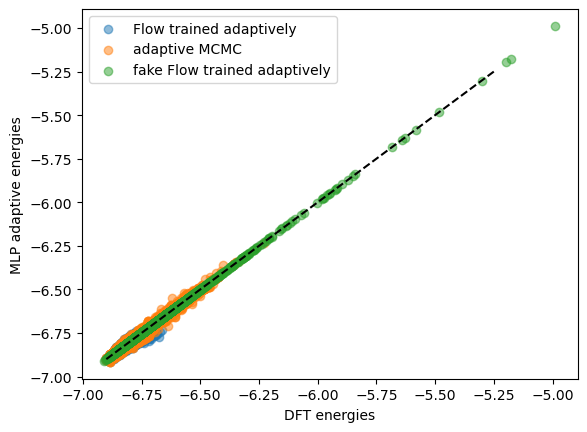

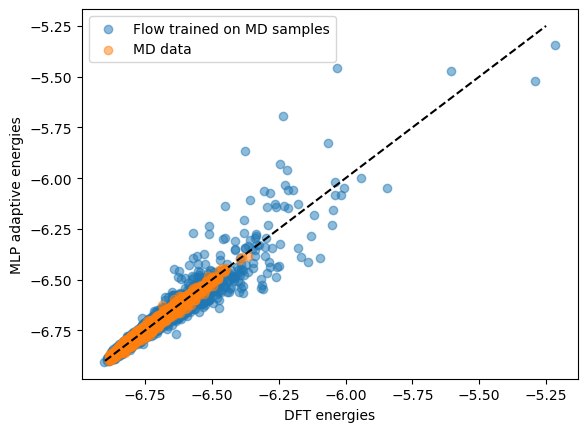

In [222]:
kind = 'MD-training'
batch_size = 1000 ## best trainings to be selected - not necessarily everywhere
df_args = dic_args[kind]

df_args_sample = dic_args['MD-sampling']

md_training_sizes = [500, 1000, 2000, 4000]

isomer_id = 0
md_training_size = 4000

df_isomer = df_args.loc[(df_args['isomer_label'] == isomer_id) & (df_args['N'] == md_training_size)]
df_isomer_sample = df_args_sample.loc[(df_args_sample['isomer_label'] == isomer_id) & (df_args['N'] == md_training_size)]

### Loading an mlp model trained on the dft data

process_id_mlp = 30019623 ## adaptive with 4000 initial MD samples ISO 0
# process_id_mlp = 30019627 ## adaptive with 4000 initial MD samples ISO 1
mlp_models = load_mlp_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')
flow_model_adaptive = load_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[-1]
prop_samples_adaptive, prop_energy_target_adaptive = load_samples_n_energies('xs_proposals', isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')
fake_prop_samples_adaptive = flow_model_adaptive.sample(prop_samples_adaptive.shape[0])
fake_prop_energy_target_adaptive = mlp_models[0](fake_prop_samples_adaptive).detach().numpy()
mc_samples_adaptive, mc_energy_target_adaptive = load_samples_n_energies('xs_adaptive', isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')


plt.figure()
plt.scatter(prop_energy_target_adaptive, mlp_models[0](prop_samples_adaptive).detach().numpy(), alpha=0.5, label='Flow trained adaptively')
plt.scatter(mc_energy_target_adaptive, mlp_models[0](mc_samples_adaptive).detach().numpy(), alpha=0.5, label='adaptive MCMC')
plt.scatter(fake_prop_energy_target_adaptive, mlp_models[0](fake_prop_samples_adaptive).detach().numpy(), alpha=0.5, label='fake Flow trained adaptively')
plt.plot([-6.9, -5.25], [-6.9, -5.25], 'k--')
plt.xlabel('DFT energies')
plt.ylabel('MLP adaptive energies')
plt.legend()

###
process_id_flow = df_isomer['process_id'].values[0]
samples_id = df_isomer_sample['process_id'].values[0]
prop_samples, prop_energy_target = load_samples_n_energies('MD-sampling', isomer_id, samples_id, project_path=subproject_path + '/3-flows-md/')
train_sample, train_energy_target = dic_md_training_datasets[isomer_id][md_training_size][:, :12], dic_md_training_datasets[isomer_id][md_training_size][:, 12]

plt.figure()
plt.scatter(prop_energy_target, mlp_models[0](prop_samples).detach().numpy(), alpha=0.5, label='Flow trained on MD samples')
plt.scatter(train_energy_target, mlp_models[0](train_sample).detach().numpy(), alpha=0.5, label='MD data')
plt.plot([-6.9, -5.25], [-6.9, -5.25], 'k--')
plt.xlabel('DFT energies')
plt.ylabel('MLP adaptive energies')
plt.legend()


In [223]:
###
seed = 42
seed = 0
torch.manual_seed(seed)
flow_model_md = load_models(isomer_id, process_id_flow, project_path=subproject_path + '/3-flows-md/')[0]

mixture = False
update_weights = False
temperature = 350
energy_type = 'mlp'

n_chains = 200

init = flow_model_md.sample(n_chains)
init = torch.cat([init, mlp_models[0](init), torch.zeros((n_chains, 1)) + isomer_id], dim=1)
n_steps = 10000

to_return_md_flow = run_metropolis(flow_model_md, init, n_chains, n_steps, energy_type,
                    temperature,
                    mixture,
                    mlp_models=mlp_models,
                    frac_computed=0.2,
                    dim=12,
                    update_weights=update_weights,
                    scheduler_weights=10,
                    alpha=0.5,
                    return_ratios=True,
                    return_proposals=True,
                    with_tqdm=True,
                    device='cpu',
                    folder_name=None,
                 )

Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Use Neural Predictor: True
Mixture Model: False


Step 3 	 Acceptance Rate 0.365:   0%|          | 0/10000 [00:00<?, ?it/s]

Step 9999 	 Acceptance Rate 0.075: 100%|██████████| 10000/10000 [01:16<00:00, 129.87it/s]


In [224]:
###
torch.manual_seed(seed)
to_return_adamc_flow = {}

train_slices = [0, 10, 30]
for train_slice in train_slices:
   flow_model_adaptive = load_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[train_slice]

   mixture = False
   update_weights = False
   temperature = 350
   energy_type = 'mlp'

   n_chains = 200

   init = flow_model_adaptive.sample(n_chains)
   init = torch.cat([init, mlp_models[0](init), torch.zeros((n_chains, 1)) + isomer_id], dim=1)
   n_steps = 10000

   to_return_adamc_flow[train_slice] = run_metropolis(flow_model_adaptive, init, n_chains, n_steps, energy_type,
                     temperature,
                     mixture,
                     mlp_models=mlp_models,
                     frac_computed=0.2,
                     dim=12,
                     update_weights=update_weights,
                     scheduler_weights=10,
                     alpha=0.5,
                     return_ratios=True,
                     return_proposals=True,
                     with_tqdm=True,
                     device='cpu',
                     folder_name=None,
                  )

Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Use Neural Predictor: True
Mixture Model: False


Step 9999 	 Acceptance Rate 0.195: 100%|██████████| 10000/10000 [01:21<00:00, 123.30it/s]


Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Use Neural Predictor: True
Mixture Model: False


Step 9999 	 Acceptance Rate 0.205: 100%|██████████| 10000/10000 [01:19<00:00, 126.34it/s]


Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Use Neural Predictor: True
Mixture Model: False


Step 9999 	 Acceptance Rate 0.210: 100%|██████████| 10000/10000 [01:18<00:00, 127.25it/s]


Text(0, 0.5, 'Acceptance rate')

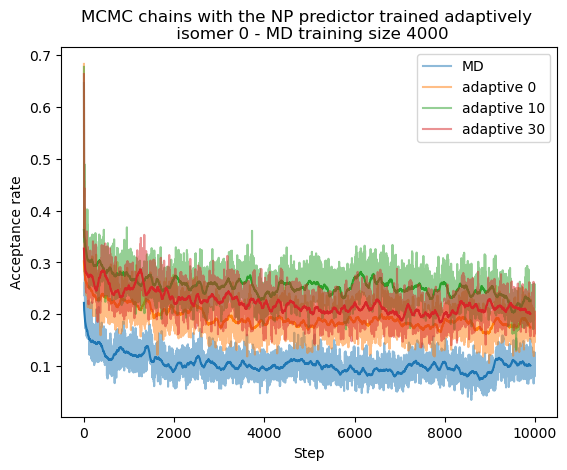

In [229]:

plt.title('MCMC chains with the NP predictor trained adaptively \n isomer {:d} - MD training size {:d}'.format(isomer_id, md_training_size))
ratios_md = to_return_md_flow['ratios']
plt.plot(torch.mean(ratios_md, dim=1), alpha=0.5, label='MD', c='C0')
plt.plot(moving_average(torch.mean(ratios_md, dim=1), 100),  c='C0')

for t,train_slice in enumerate(train_slices):
    ratios_adaptive = to_return_adamc_flow[train_slice]['ratios']
    plt.plot(torch.mean(ratios_adaptive, dim=1), alpha=0.5, label='adaptive {:d}'.format(train_slice), c='C{:d}'.format(t+1))
    plt.plot(moving_average(torch.mean(ratios_adaptive, dim=1), 100), c='C{:d}'.format(t+1))


plt.legend()
plt.xlabel('Step')
plt.ylabel('Acceptance rate')
# plt.xscale('log')


In [196]:
# VERSION ALL THE CHAINS TOGETHER

#plt.figure(figsize=(15, 5))
# plt.title('MCMC chains with the NP predictor trained adaptively \n isomer {:d} - MD training size {:d} - seed {:d}'.format(isomer_id, md_training_size, seed))
# axs = [plt.subplot(1, 2, i+1) for i in range(2)]
# plt.sca(axs[0])
# plt.plot(r_hat_md[1], r_hat_md[0], '.-', label='MD', c='C0')
# plt.plot(r_hat_adaptive[1], r_hat_adaptive[0], '.-', label='adaptive', c='C1')
# handles_, labels_ = plt.gca().get_legend_handles_labels()
# plt.legend(handles=[handles_[0],handles_[-1]], labels=[labels_[0],labels_[-1]], loc='lower center')
# plt.axhline(1.01, c='k', ls='--')
# plt.xlabel('Step')
# plt.ylabel('R_hat - coordinates')

# r_hat_md = R_hat(to_return_md_flow['us'].unsqueeze(-1).numpy().swapaxes(0, 1), burn_in=100, n_split=10)
# r_hat_adaptive = R_hat(to_return_adamc_flow['us'].unsqueeze(-1).numpy().swapaxes(0, 1), burn_in=100, n_split=10)

# plt.sca(axs[1])
# plt.plot(r_hat_md[1], r_hat_md[0], '.-', label='MD', c='C0')
# plt.plot(r_hat_adaptive[1], r_hat_adaptive[0], '.-', label='adaptive', c='C1')
# handles_, labels_ = plt.gca().get_legend_handles_labels()
# plt.legend(handles=[handles_[0],handles_[-1]], labels=[labels_[0],labels_[-1]], loc='lower center')
# plt.axhline(1.01, c='k', ls='--')
# plt.xlabel('Step')
# plt.ylabel('R_hat - U')

In [197]:
r_hat_md_s = []
r_hat_u_md_s = []
r_hat_adaptive_s = []
r_hat_adaptive_u_s = []

n_split_chains = 5
for split in range(n_split_chains):  
    n_chain_per_split = n_chains // n_split_chains 
    r_hat_md = R_hat(to_return_md_flow['xs'][:, split*n_chain_per_split:(split+1)*n_chain_per_split].numpy().swapaxes(0, 1), burn_in=100, n_split=10)
    r_hat_adaptive = R_hat(to_return_adamc_flow['xs'][:, split*n_chain_per_split:(split+1)*n_chain_per_split].numpy().swapaxes(0, 1), burn_in=100, n_split=10)
    r_hat_md_s.append(r_hat_md[0])
    r_hat_adaptive_s.append(r_hat_adaptive[0])

    r_hat_u_md = R_hat(to_return_md_flow['us'][:, split*n_chain_per_split:(split+1)*n_chain_per_split].unsqueeze(-1).numpy().swapaxes(0, 1), burn_in=100, n_split=10)
    r_hat_u_adaptive = R_hat(to_return_adamc_flow['us'][:, split*n_chain_per_split:(split+1)*n_chain_per_split].unsqueeze(-1).numpy().swapaxes(0, 1), burn_in=100, n_split=10)
    r_hat_u_md_s.append(r_hat_u_md[0])
    r_hat_adaptive_u_s.append(r_hat_u_adaptive[0])
    
r_hat_it_splits = r_hat_adaptive[1]

In [198]:
r_hat_adaptive_ss = np.array(r_hat_adaptive_s)
r_hat_md_ss = np.array(r_hat_md_s)
r_hat_adaptive_u_ss = np.array(r_hat_adaptive_u_s)
r_hat_md_u_ss = np.array(r_hat_u_md_s)
r_hat_md_u_ss.shape

(5, 10, 1)

/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_31284/2499160610.py:3: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  axs = [plt.subplot(1, 2, i+1) for i in range(2)]


Text(0, 0.5, 'R_hat - U')

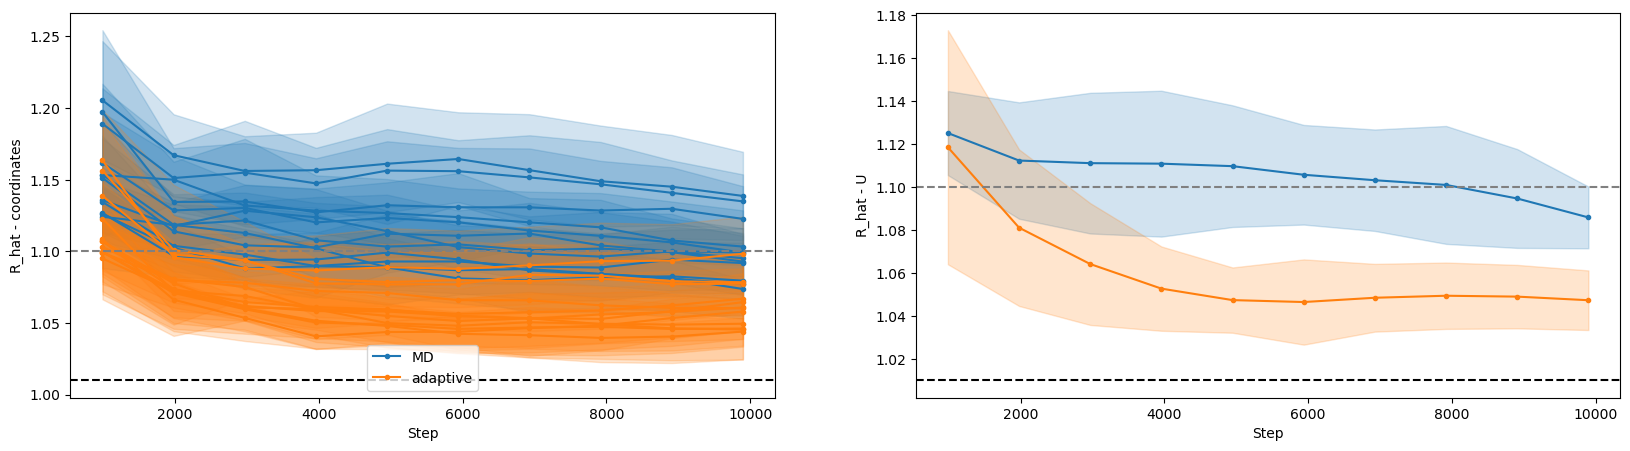

In [199]:
plt.figure(figsize=(20, 5))
plt.title('MCMC chains with the NP predictor trained adaptively \n isomer {:d} - MD training size {:d} - seed {:d}'.format(isomer_id, md_training_size, seed))
axs = [plt.subplot(1, 2, i+1) for i in range(2)]
plt.sca(axs[0])
plt.plot(r_hat_it_splits, r_hat_md_ss.mean(axis=0), '.-', label='MD', c='C0')
for c in range(r_hat_md_ss.shape[2]):
    plt.fill_between(r_hat_it_splits, r_hat_md_ss.mean(axis=0)[:, c] - r_hat_md_ss.std(axis=0)[:, c],
                      r_hat_md_ss.mean(axis=0)[:, c] + r_hat_md_ss.std(axis=0)[:, c], alpha=0.2, color='C0')

plt.plot(r_hat_it_splits, r_hat_adaptive_ss.mean(axis=0), '.-', label='adaptive', c='C1')
for c in range(r_hat_adaptive_ss.shape[2]):
    plt.fill_between(r_hat_it_splits, r_hat_adaptive_ss.mean(axis=0)[:, c] - r_hat_adaptive_ss.std(axis=0)[:, c], 
                     r_hat_adaptive_ss.mean(axis=0)[:, c] + r_hat_adaptive_ss.std(axis=0)[:, c], alpha=0.2, color='C1')

handles_, labels_ = plt.gca().get_legend_handles_labels()
plt.legend(handles=[handles_[0],handles_[-1]], labels=[labels_[0],labels_[-1]], loc='lower center')
plt.axhline(1.01, c='k', ls='--')
plt.axhline(1.1, c='gray', ls='--')
plt.xlabel('Step')
plt.ylabel('R_hat - coordinates')

plt.sca(axs[1])
plt.plot(r_hat_it_splits, r_hat_md_u_ss.mean(axis=0), '.-', label='MD', c='C0')
plt.fill_between(r_hat_it_splits, (r_hat_md_u_ss.mean(axis=0) - r_hat_md_u_ss.std(axis=0))[:,0],
                  (r_hat_md_u_ss.mean(axis=0) + r_hat_md_u_ss.std(axis=0))[:,0], alpha=0.2, color='C0')
plt.plot(r_hat_it_splits, r_hat_adaptive_u_ss.mean(axis=0), '.-', label='adaptive', c='C1')
plt.fill_between(r_hat_it_splits, (r_hat_adaptive_u_ss.mean(axis=0) - r_hat_adaptive_u_ss.std(axis=0))[:,0], 
                 (r_hat_adaptive_u_ss.mean(axis=0) + r_hat_adaptive_u_ss.std(axis=0))[:,0], alpha=0.2, color='C1')
plt.axhline(1.01, c='k', ls='--')
plt.axhline(1.1, c='gray', ls='--')
plt.xlabel('Step')
plt.ylabel('R_hat - U')


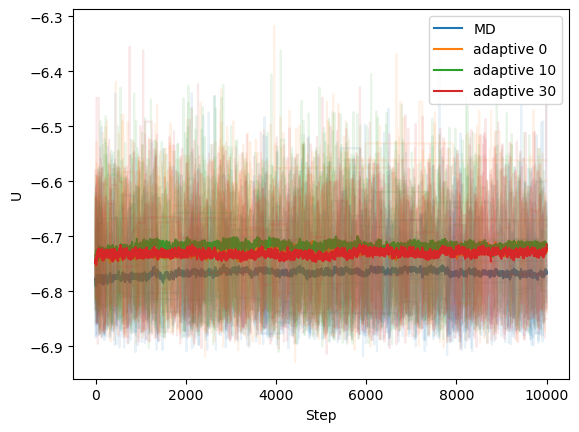

In [232]:


plt.plot(to_return_md_flow['us'].numpy()[:,:10], '-', alpha=0.1, c='C0')
plt.plot(to_return_md_flow['us'].numpy().mean(axis=1), '-', label='MD', c='C0')
for t,train_slice in enumerate(train_slices):
    plt.plot(to_return_adamc_flow[train_slice]['us'].numpy()[:,:5], '-', alpha=0.1, c='C{:d}'.format(t+1))
    plt.plot(to_return_adamc_flow[train_slice]['us'].numpy().mean(axis=1), '-', label='adaptive {:d}'.format(train_slice), c='C{:d}'.format(t+1))
# plt.plot(to_return_adamc_flow['us'].numpy()[:,:10], '-', alpha=0.1, c='C1')
# plt.plot(to_return_adamc_flow['us'].numpy().mean(axis=1), '-', label='adaptive', c='C1')
plt.ylabel('U')
plt.xlabel('Step')
plt.legend()

## 1.2 -  Metropolis-Hasting on isomer 1 - USING THE MLP MODEL TRAINED ADAPTIVELY
--> something is strange here because the adaptive MCMC has plummeting energies 

--> maybe things are going a bit "dans le décor", finding very low energy conformations that are maybe out of the training sets of the MLP? for isomer 1, the engies are typically not that low

--> we never did chains so long

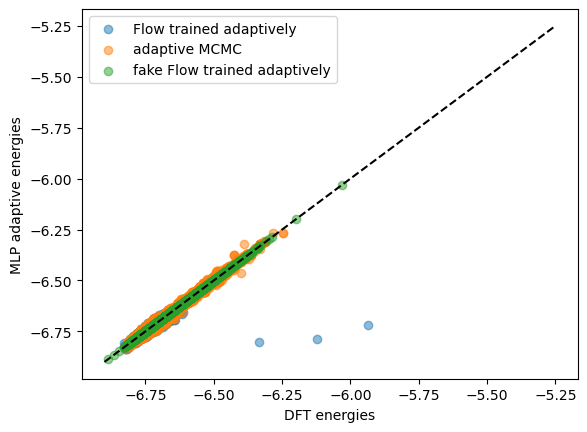

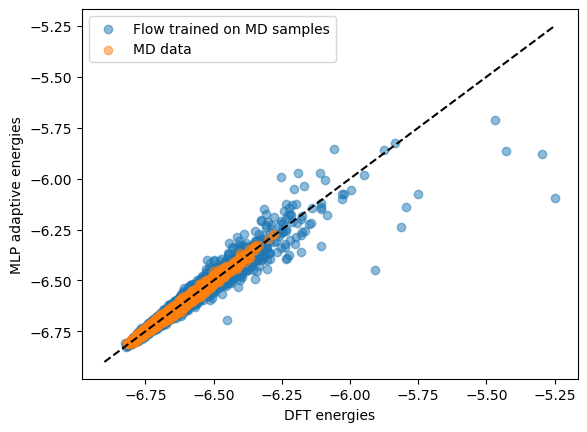

In [238]:
kind = 'MD-training'
batch_size = 1000 ## best trainings to be selected - not necessarily everywhere
df_args = dic_args[kind]

df_args_sample = dic_args['MD-sampling']

md_training_sizes = [500, 1000, 2000, 4000]

isomer_id = 1
md_training_size = 4000

df_isomer = df_args.loc[(df_args['isomer_label'] == isomer_id) & (df_args['N'] == md_training_size)]
df_isomer_sample = df_args_sample.loc[(df_args_sample['isomer_label'] == isomer_id) & (df_args['N'] == md_training_size)]

### Loading an mlp model trained on the dft data

# process_id_mlp = 30019623 ## adaptive with 4000 initial MD samples ISO 0
process_id_mlp = 30019627 ## adaptive with 4000 initial MD samples ISO 1
mlp_models = load_mlp_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')
flow_model_adaptive = load_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[-1]
prop_samples_adaptive, prop_energy_target_adaptive = load_samples_n_energies('xs_proposals', isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')
fake_prop_samples_adaptive = flow_model_adaptive.sample(prop_samples_adaptive.shape[0])
fake_prop_energy_target_adaptive = mlp_models[0](fake_prop_samples_adaptive).detach().numpy()
mc_samples_adaptive, mc_energy_target_adaptive = load_samples_n_energies('xs_adaptive', isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')


plt.figure()
plt.scatter(prop_energy_target_adaptive, mlp_models[0](prop_samples_adaptive).detach().numpy(), alpha=0.5, label='Flow trained adaptively')
plt.scatter(mc_energy_target_adaptive, mlp_models[0](mc_samples_adaptive).detach().numpy(), alpha=0.5, label='adaptive MCMC')
plt.scatter(fake_prop_energy_target_adaptive, mlp_models[0](fake_prop_samples_adaptive).detach().numpy(), alpha=0.5, label='fake Flow trained adaptively')
plt.plot([-6.9, -5.25], [-6.9, -5.25], 'k--')
plt.xlabel('DFT energies')
plt.ylabel('MLP adaptive energies')
plt.legend()

###
process_id_flow = df_isomer['process_id'].values[0]
samples_id = df_isomer_sample['process_id'].values[0]
prop_samples, prop_energy_target = load_samples_n_energies('MD-sampling', isomer_id, samples_id, project_path=subproject_path + '/3-flows-md/')
train_sample, train_energy_target = dic_md_training_datasets[isomer_id][md_training_size][:, :12], dic_md_training_datasets[isomer_id][md_training_size][:, 12]

plt.figure()
plt.scatter(prop_energy_target, mlp_models[0](prop_samples).detach().numpy(), alpha=0.5, label='Flow trained on MD samples')
plt.scatter(train_energy_target, mlp_models[0](train_sample).detach().numpy(), alpha=0.5, label='MD data')
plt.plot([-6.9, -5.25], [-6.9, -5.25], 'k--')
plt.xlabel('DFT energies')
plt.ylabel('MLP adaptive energies')
plt.legend()


In [239]:
isomer_id

1

In [240]:
###
seed = 42
# seed = 0
torch.manual_seed(seed)
flow_model_md = load_models(isomer_id, process_id_flow, project_path=subproject_path + '/3-flows-md/')[0]

mixture = False
update_weights = False
temperature = 350
energy_type = 'mlp'

n_chains = 200

init = flow_model_md.sample(n_chains)
init = torch.cat([init, mlp_models[0](init), torch.zeros((n_chains, 1)) + isomer_id], dim=1)
n_steps = 10000

to_return_md_flow = run_metropolis(flow_model_md, init, n_chains, n_steps, energy_type,
                    temperature,
                    mixture,
                    mlp_models=mlp_models,
                    frac_computed=0.2,
                    dim=12,
                    update_weights=update_weights,
                    scheduler_weights=10,
                    alpha=0.5,
                    return_ratios=True,
                    return_proposals=True,
                    with_tqdm=True,
                    device='cpu',
                    folder_name=None,
                 )

Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Use Neural Predictor: True
Mixture Model: False


Step 9999 	 Acceptance Rate 0.085: 100%|██████████| 10000/10000 [01:15<00:00, 133.32it/s]


In [245]:
###
torch.manual_seed(seed)
to_return_adamc_flow = {}
train_slices = [0, 10, 30]
for train_slice in train_slices:
   flow_model_adaptive = load_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[train_slice]

   mixture = False
   update_weights = False
   temperature = 350
   energy_type = 'mlp'

   n_chains = 20

   init = flow_model_adaptive.sample(n_chains)
   init = torch.cat([init, mlp_models[0](init), torch.zeros((n_chains, 1)) + isomer_id], dim=1)
   n_steps = 20000

   to_return_adamc_flow[train_slice] = run_metropolis(flow_model_adaptive, init, n_chains, n_steps, energy_type,
                     temperature,
                     mixture,
                     mlp_models=mlp_models,
                     frac_computed=0.2,
                     dim=12,
                     update_weights=update_weights,
                     scheduler_weights=10,
                     alpha=0.5,
                     return_ratios=True,
                     return_proposals=True,
                     with_tqdm=True,
                     device='cpu',
                     folder_name=None,
                  )

Running Metropolis-Hastings
Number of chains: 20
Number of steps: 20000
Temperature: 350.0K
Energy Type: mlp
Use Neural Predictor: True
Mixture Model: False


Step 19999 	 Acceptance Rate 0.300: 100%|██████████| 20000/20000 [01:28<00:00, 224.88it/s]


Running Metropolis-Hastings
Number of chains: 20
Number of steps: 20000
Temperature: 350.0K
Energy Type: mlp
Use Neural Predictor: True
Mixture Model: False


Step 19999 	 Acceptance Rate 0.200: 100%|██████████| 20000/20000 [01:31<00:00, 218.34it/s]


Running Metropolis-Hastings
Number of chains: 20
Number of steps: 20000
Temperature: 350.0K
Energy Type: mlp
Use Neural Predictor: True
Mixture Model: False


Step 19999 	 Acceptance Rate 0.000: 100%|██████████| 20000/20000 [01:32<00:00, 215.82it/s]


Text(0, 0.5, 'Acceptance rate')

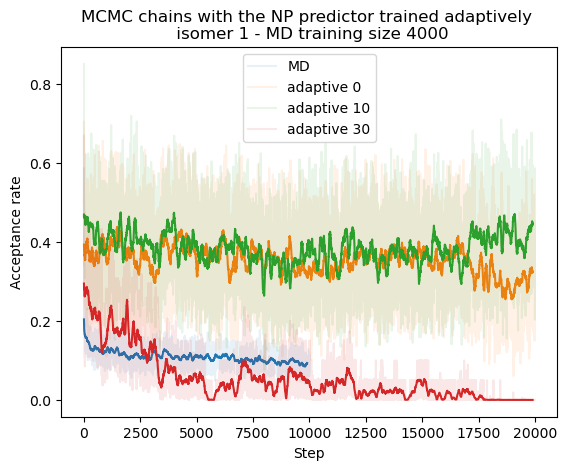

In [248]:
plt.title('MCMC chains with the NP predictor trained adaptively \n isomer {:d} - MD training size {:d}'.format(isomer_id, md_training_size))
ratios_md = to_return_md_flow['ratios']
plt.plot(torch.mean(ratios_md, dim=1), alpha=0.1, label='MD', c='C0')
plt.plot(moving_average(torch.mean(ratios_md, dim=1), 100),  c='C0')

for t,train_slice in enumerate(train_slices):
    ratios_adaptive = to_return_adamc_flow[train_slice]['ratios']
    plt.plot(torch.mean(ratios_adaptive, dim=1), alpha=0.1, label='adaptive {:d}'.format(train_slice), c='C{:d}'.format(t+1))
    plt.plot(moving_average(torch.mean(ratios_adaptive, dim=1), 100), c='C{:d}'.format(t+1))


plt.legend()
plt.xlabel('Step')
plt.ylabel('Acceptance rate')
# plt.xscale('log'))


In [229]:
r_hat_md_s = []
r_hat_u_md_s = []
r_hat_adaptive_s = []
r_hat_adaptive_u_s = []

n_split_chains = 5
for split in range(n_split_chains):  
    n_chain_per_split = n_chains // n_split_chains 
    r_hat_md = R_hat(to_return_md_flow['xs'][:, split*n_chain_per_split:(split+1)*n_chain_per_split].numpy().swapaxes(0, 1), burn_in=100, n_split=10)
    r_hat_adaptive = R_hat(to_return_adamc_flow['xs'][:, split*n_chain_per_split:(split+1)*n_chain_per_split].numpy().swapaxes(0, 1), burn_in=100, n_split=10)
    r_hat_md_s.append(r_hat_md[0])
    r_hat_adaptive_s.append(r_hat_adaptive[0])

    r_hat_u_md = R_hat(to_return_md_flow['us'][:, split*n_chain_per_split:(split+1)*n_chain_per_split].unsqueeze(-1).numpy().swapaxes(0, 1), burn_in=100, n_split=10)
    r_hat_u_adaptive = R_hat(to_return_adamc_flow['us'][:, split*n_chain_per_split:(split+1)*n_chain_per_split].unsqueeze(-1).numpy().swapaxes(0, 1), burn_in=100, n_split=10)
    r_hat_u_md_s.append(r_hat_u_md[0])
    r_hat_adaptive_u_s.append(r_hat_u_adaptive[0])
    
r_hat_it_splits = r_hat_adaptive[1]

In [230]:
r_hat_adaptive_ss = np.array(r_hat_adaptive_s)
r_hat_md_ss = np.array(r_hat_md_s)
r_hat_adaptive_u_ss = np.array(r_hat_adaptive_u_s)
r_hat_md_u_ss = np.array(r_hat_u_md_s)
r_hat_md_u_ss.shape

(5, 10, 1)

/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_31284/2499160610.py:3: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  axs = [plt.subplot(1, 2, i+1) for i in range(2)]


Text(0, 0.5, 'R_hat - U')

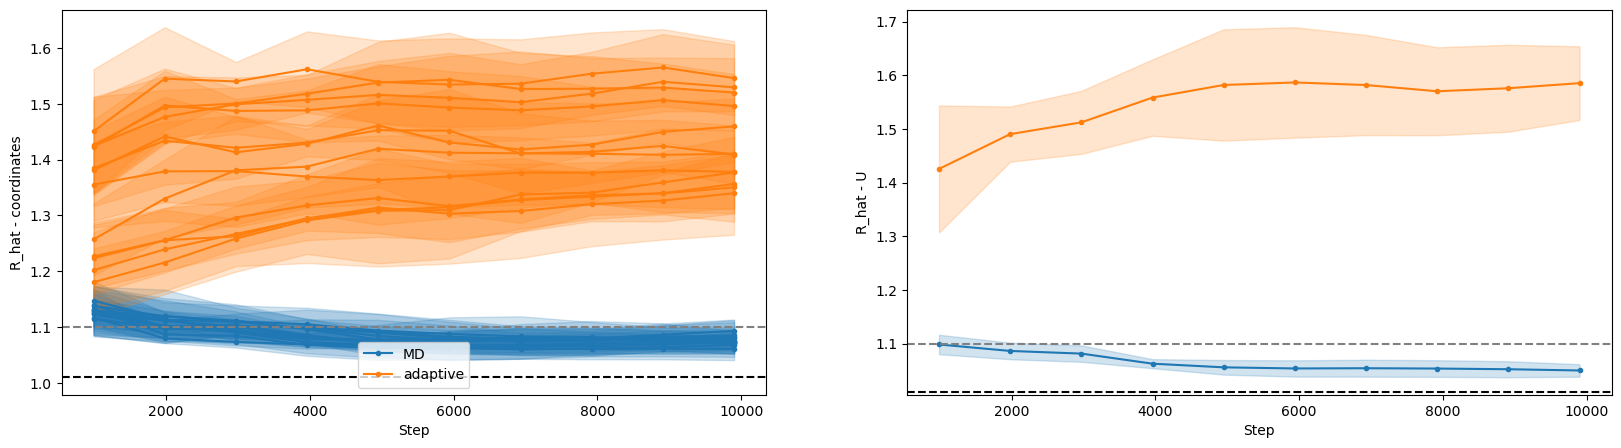

In [231]:
plt.figure(figsize=(20, 5))
plt.title('MCMC chains with the NP predictor trained adaptively \n isomer {:d} - MD training size {:d} - seed {:d}'.format(isomer_id, md_training_size, seed))
axs = [plt.subplot(1, 2, i+1) for i in range(2)]
plt.sca(axs[0])
plt.plot(r_hat_it_splits, r_hat_md_ss.mean(axis=0), '.-', label='MD', c='C0')
for c in range(r_hat_md_ss.shape[2]):
    plt.fill_between(r_hat_it_splits, r_hat_md_ss.mean(axis=0)[:, c] - r_hat_md_ss.std(axis=0)[:, c],
                      r_hat_md_ss.mean(axis=0)[:, c] + r_hat_md_ss.std(axis=0)[:, c], alpha=0.2, color='C0')

plt.plot(r_hat_it_splits, r_hat_adaptive_ss.mean(axis=0), '.-', label='adaptive', c='C1')
for c in range(r_hat_adaptive_ss.shape[2]):
    plt.fill_between(r_hat_it_splits, r_hat_adaptive_ss.mean(axis=0)[:, c] - r_hat_adaptive_ss.std(axis=0)[:, c], 
                     r_hat_adaptive_ss.mean(axis=0)[:, c] + r_hat_adaptive_ss.std(axis=0)[:, c], alpha=0.2, color='C1')

handles_, labels_ = plt.gca().get_legend_handles_labels()
plt.legend(handles=[handles_[0],handles_[-1]], labels=[labels_[0],labels_[-1]], loc='lower center')
plt.axhline(1.01, c='k', ls='--')
plt.axhline(1.1, c='gray', ls='--')
plt.xlabel('Step')
plt.ylabel('R_hat - coordinates')

plt.sca(axs[1])
plt.plot(r_hat_it_splits, r_hat_md_u_ss.mean(axis=0), '.-', label='MD', c='C0')
plt.fill_between(r_hat_it_splits, (r_hat_md_u_ss.mean(axis=0) - r_hat_md_u_ss.std(axis=0))[:,0],
                  (r_hat_md_u_ss.mean(axis=0) + r_hat_md_u_ss.std(axis=0))[:,0], alpha=0.2, color='C0')
plt.plot(r_hat_it_splits, r_hat_adaptive_u_ss.mean(axis=0), '.-', label='adaptive', c='C1')
plt.fill_between(r_hat_it_splits, (r_hat_adaptive_u_ss.mean(axis=0) - r_hat_adaptive_u_ss.std(axis=0))[:,0], 
                 (r_hat_adaptive_u_ss.mean(axis=0) + r_hat_adaptive_u_ss.std(axis=0))[:,0], alpha=0.2, color='C1')
plt.axhline(1.01, c='k', ls='--')
plt.axhline(1.1, c='gray', ls='--')
plt.xlabel('Step')
plt.ylabel('R_hat - U')


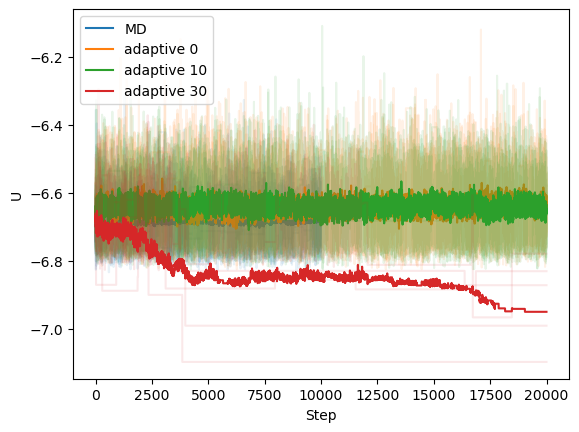

In [247]:
plt.plot(to_return_md_flow['us'].numpy()[:,:10], '-', alpha=0.1, c='C0')
plt.plot(to_return_md_flow['us'].numpy().mean(axis=1), '-', label='MD', c='C0')
for t,train_slice in enumerate(train_slices):
    plt.plot(to_return_adamc_flow[train_slice]['us'].numpy()[:,:5], '-', alpha=0.1, c='C{:d}'.format(t+1))
    plt.plot(to_return_adamc_flow[train_slice]['us'].numpy().mean(axis=1), '-', label='adaptive {:d}'.format(train_slice), c='C{:d}'.format(t+1))
# plt.plot(to_return_adamc_flow['us'].numpy()[:,:10], '-', alpha=0.1, c='C1')
# plt.plot(to_return_adamc_flow['us'].numpy().mean(axis=1), '-', label='adaptive', c='C1')
plt.ylabel('U')
plt.xlabel('Step')
plt.legend()

#  2 - Mixture Metropolis-Hastings on mixture using the MLP model trained adaptively

## 2.1 - Flows trained adaptively

In [61]:
from flonacomldft.models.mixture import Mixture

model_labels = [0, 1]
process_id_mlp_s = [30019623, 30019627] ## adaptive with 4000 initial MD samples ISO 0
# process_id_mlp = 30019627 ## adaptive with 4000 initial MD samples ISO 1

flow_model_adaptive_s = []  
mlp_model_s = []
flow_train_slice = 0

for isomer_id, process_id_mlp in zip(model_labels, process_id_mlp_s):
    mlp_model = load_mlp_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[0]
    flow_model_adaptive = load_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[flow_train_slice]

    mlp_model_s.append(mlp_model)
    flow_model_adaptive_s.append(flow_model_adaptive)

mixture_model = Mixture(flow_model_adaptive_s)
mixture_model.weights 

tensor([0.5000, 0.5000], requires_grad=True)

In [62]:
seed = 50
seed = 34
torch.manual_seed(seed)

mixture = True
update_weights = False
temperature = 350
energy_type = 'mlp'

n_chains = 1000

init = flow_model_adaptive_s[1].sample(n_chains)
init = torch.cat([init, mlp_model_s[1](init), torch.zeros((n_chains, 1)) + isomer_id], dim=1)
n_steps = 2000

to_return_adamc_flow = run_metropolis(mixture_model, init, n_chains, n_steps, energy_type,
                    temperature,
                    mixture,
                    mlp_models=mlp_model_s,
                    frac_computed=0.2,
                    dim=12,
                    update_weights=update_weights,
                    scheduler_weights=10,
                    alpha=0.5,
                    return_ratios=True,
                    return_proposals=True,
                    with_tqdm=True,
                    device='cpu',
                    folder_name=None,
                 )

Running Metropolis-Hastings
Number of chains: 1000
Number of steps: 2000
Temperature: 350.0K
Energy Type: mlp
Mixture model
Use Neural Predictor: True
Mixture Model: True


  0%|          | 0/2000 [00:00<?, ?it/s]

Step 1999 	 Acceptance Rate 0.115: 100%|██████████| 2000/2000 [00:54<00:00, 36.38it/s]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0, 0.5, 'Chain')

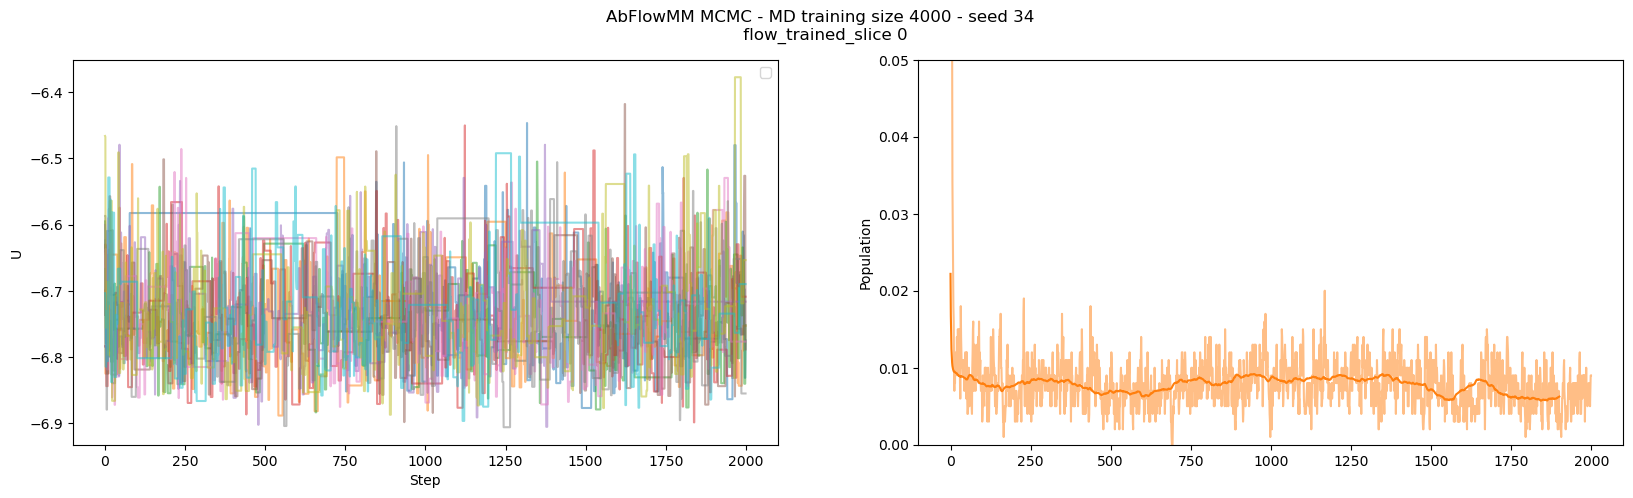

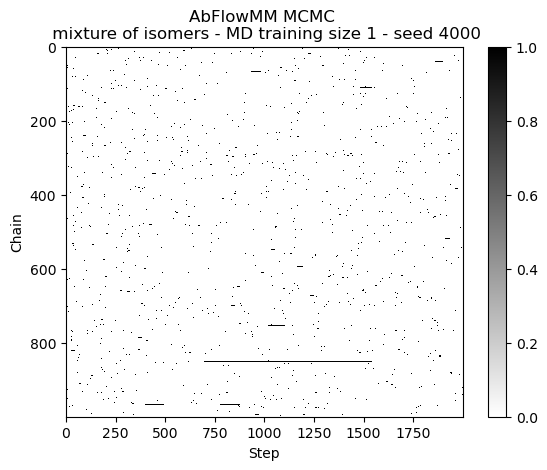

In [64]:
plt.figure(figsize=(20, 5))
plt.suptitle('AbFlowMM MCMC - MD training size {:d} - seed {:d} \n flow_trained_slice {:d}'.format( md_training_size, seed, flow_train_slice))
axs = [plt.subplot(1, 2, i+1) for i in range(2)]

plt.sca(axs[0])
plt.plot(to_return_adamc_flow['us'].numpy()[:,:10], '-', alpha=0.5)
# plt.plot(to_return_adamc_flow['us'].numpy().mean(axis=1), '-', label='adaptive', c='C1')
plt.ylabel('U')
plt.xlabel('Step')

plt.legend()

pop = to_return_adamc_flow['isomers'].numpy().mean(axis=1)

plt.sca(axs[1])
plt.plot(pop, '-', alpha=0.5, c='C1')
plt.plot(moving_average(pop, 100), '-', c='C1')
plt.ylim([0, 0.05])
plt.ylabel('Population')

plt.figure()
plt.title('AbFlowMM MCMC \n mixture of isomers - MD training size {:d} - seed {:d}'.format(isomer_id, md_training_size, seed))
plt.imshow(to_return_adamc_flow['isomers'].numpy().T, aspect='auto', cmap='gray_r', interpolation='none')
plt.colorbar()

plt.xlabel('Step')
plt.ylabel('Chain')

## 2.1 - Flows trained on MD only

In [65]:
kind = 'MD-training'
batch_size = 1000 ## best trainings to be selected - not necessarily everywhere
df_args = dic_args[kind]

df_args_sample = dic_args['MD-sampling']

md_training_sizes = [500, 1000, 2000, 4000]

md_training_size = 4000

isomer_id = 0
flow_model_md_s = []

mlp_model_s = []

for isomer_id, process_id_mlp in zip(model_labels, process_id_mlp_s):
    mlp_model = load_mlp_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[0]
    mlp_model_s.append(mlp_model)

for isomer_id in mode_labels:
    df_isomer = df_args.loc[(df_args['isomer_label'] == isomer_id) & (df_args['N'] == md_training_size)]
    df_isomer_sample = df_args_sample.loc[(df_args_sample['isomer_label'] == isomer_id) & (df_args['N'] == md_training_size)]
    process_id_flow = df_isomer['process_id'].values[0]
    samples_id = df_isomer_sample['process_id'].values[0]
    flow_model_md = load_models(isomer_id, process_id_flow, project_path=subproject_path + '/3-flows-md/')[0]
    flow_model_md_s.append(flow_model_md)

mixture_model = Mixture(flow_model_md_s)
mixture_model.weights 

tensor([0.5000, 0.5000], requires_grad=True)

In [66]:
seed = 50
# seed = 34
torch.manual_seed(seed)

mixture = True
update_weights = False
temperature = 350
energy_type = 'mlp'

n_chains = 1000

init = flow_model_md_s[1].sample(n_chains)
init = torch.cat([init, mlp_model_s[1](init), torch.zeros((n_chains, 1)) + isomer_id], dim=1)
n_steps = 4000

to_return_md_flow = run_metropolis(mixture_model, init, n_chains, n_steps, energy_type,
                    temperature,
                    mixture,
                    mlp_models=mlp_model_s,
                    frac_computed=0.2,
                    dim=12,
                    update_weights=update_weights,
                    scheduler_weights=10,
                    alpha=0.5,
                    return_ratios=True,
                    return_proposals=True,
                    with_tqdm=True,
                    device='cpu',
                    folder_name=None,
                 )



Running Metropolis-Hastings
Number of chains: 1000
Number of steps: 4000
Temperature: 350.0K
Energy Type: mlp
Mixture model
Use Neural Predictor: True
Mixture Model: True


Step 3999 	 Acceptance Rate 0.059: 100%|██████████| 4000/4000 [01:40<00:00, 39.69it/s]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0, 0.5, 'Chain')

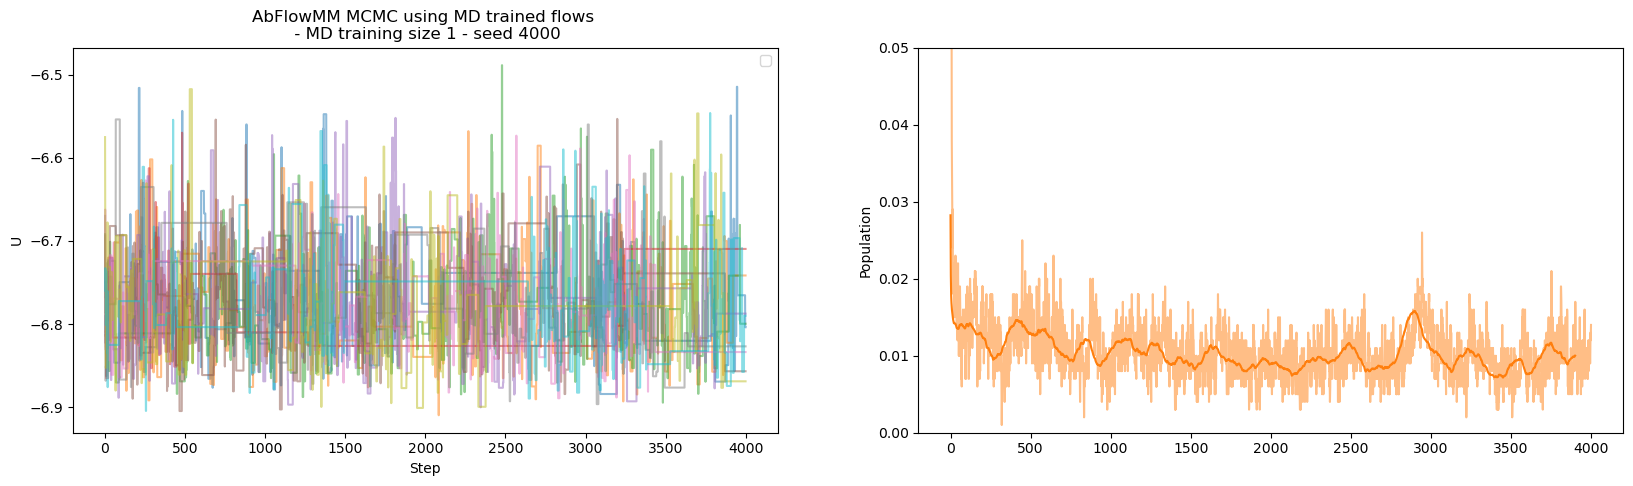

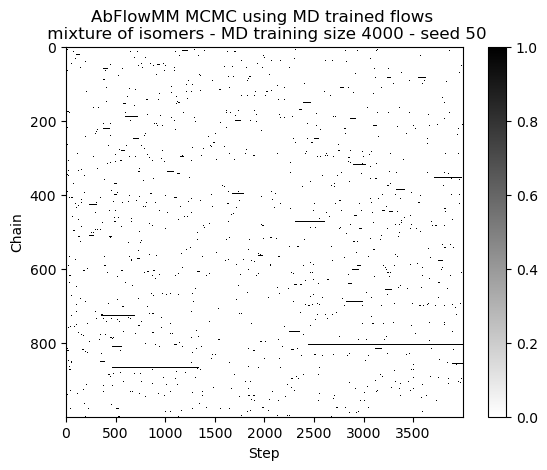

In [67]:
plt.figure(figsize=(20, 5))
axs = [plt.subplot(1, 2, i+1) for i in range(2)]

plt.sca(axs[0])
plt.plot(to_return_md_flow['us'].numpy()[:,:10], '-', alpha=0.5)
# plt.plot(to_return_md_flow['us'].numpy().mean(axis=1), '-', label='adaptive', c='C1')
plt.ylabel('U')
plt.xlabel('Step')
plt.title('AbFlowMM MCMC using MD trained flows \n - MD training size {:d} - seed {:d}'.format(isomer_id, md_training_size, seed))
plt.legend()

pop = to_return_md_flow['isomers'].numpy().mean(axis=1)

plt.sca(axs[1])
plt.plot(pop, '-', alpha=0.5, c='C1')
plt.plot(moving_average(pop, 100), '-', c='C1')
plt.ylim([0, 0.05])
plt.ylabel('Population')

plt.figure()
plt.title('AbFlowMM MCMC using MD trained flows \n mixture of isomers - MD training size {:d} - seed {:d}'.format( md_training_size, seed))
plt.imshow(to_return_md_flow['isomers'].numpy().T, aspect='auto', cmap='gray_r', interpolation='none')
plt.colorbar()
plt.xlabel('Step')
plt.ylabel('Chain')

### 2.2.2 - adapting the weights during the MCMC

In [33]:
seed = 50
seed = 34
torch.manual_seed(seed)

mixture = True
update_weights = True
temperature = 350
energy_type = 'mlp'

n_chains = 1000

init = flow_model_md_s[1].sample(n_chains)
init = torch.cat([init, mlp_model_s[1](init), torch.zeros((n_chains, 1)) + isomer_id], dim=1)
n_steps = 4000

to_return_md_flow = run_metropolis(mixture_model, init, n_chains, n_steps, energy_type,
                    temperature,
                    mixture,
                    mlp_models=mlp_model_s,
                    frac_computed=0.2,
                    dim=12,
                    update_weights=update_weights,
                    scheduler_weights=10,
                    alpha=0.5,
                    return_ratios=True,
                    return_proposals=True,
                    with_tqdm=True,
                    device='cpu',
                    folder_name=None,
                 )



Running Metropolis-Hastings
Number of chains: 1000
Number of steps: 4000
Temperature: 350.0K
Energy Type: mlp
Mixture model
Use Neural Predictor: True
Mixture Model: True


Step 3999 	 Acceptance Rate 0.070: 100%|██████████| 4000/4000 [01:42<00:00, 38.91it/s]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0, 0.5, 'Chain')

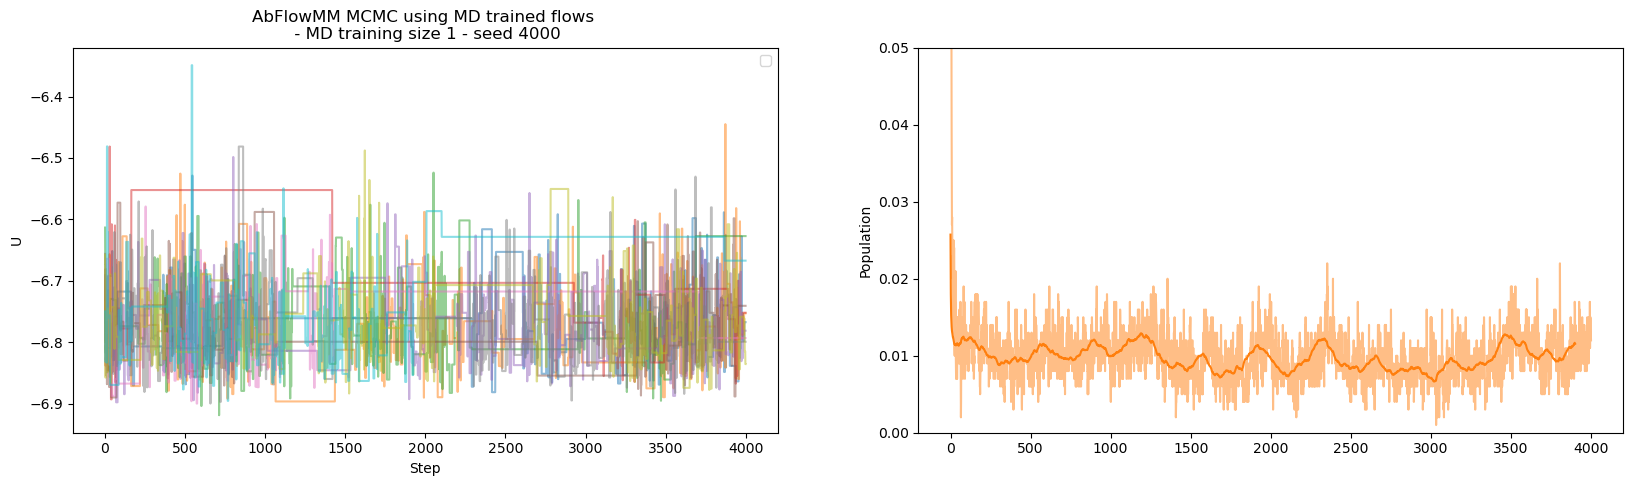

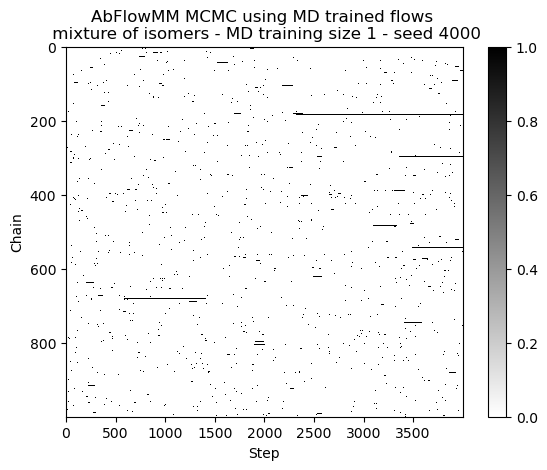

In [34]:
plt.figure(figsize=(20, 5))
axs = [plt.subplot(1, 2, i+1) for i in range(2)]

plt.sca(axs[0])
plt.plot(to_return_md_flow['us'].numpy()[:,:10], '-', alpha=0.5)
# plt.plot(to_return_md_flow['us'].numpy().mean(axis=1), '-', label='adaptive', c='C1')
plt.ylabel('U')
plt.xlabel('Step')
plt.title('AbFlowMM MCMC using MD trained flows \n - MD training size {:d} - seed {:d}'.format(isomer_id, md_training_size, seed))
plt.legend()

pop = to_return_md_flow['isomers'].numpy().mean(axis=1)

plt.sca(axs[1])
plt.plot(pop, '-', alpha=0.5, c='C1')
plt.plot(moving_average(pop, 100), '-', c='C1')
plt.ylim([0, 0.05])
plt.ylabel('Population')

plt.figure()
plt.title('AbFlowMM MCMC using MD trained flows \n mixture of isomers - MD training size {:d} - seed {:d}'.format(isomer_id, md_training_size, seed))
plt.imshow(to_return_md_flow['isomers'].numpy().T, aspect='auto', cmap='gray_r', interpolation='none')
plt.colorbar()
plt.xlabel('Step')
plt.ylabel('Chain')

# 3 - back to deepBAR - using the MLP model trained adaptively to power the MCMC & the free energy estimator

In [188]:
# dic_results_all = {'kind': [], 'isomer_id': [], 'md_training_size': [],'process_id_flow': [],
#                     'mc seed': [],  'flow_train_slice': [], 'log_r':[], 'trial': []}

# to_return_md_flow_isomer_0 = {}
# to_return_md_flow_isomer_1 = {}

# to_return_adamc_flow_isomer_0 = {}
# to_return_adamc_flow_isomer_1 = {}

## 3.1 - doing it for each isomer separately and combining

### 3.1.1 - MD flows

In [189]:
flow_train_slice = -1

seed = 42
seed = 0
torch.manual_seed(seed)

isomer_id = 0
md_training_size = 4000

df_isomer = df_args.loc[(df_args['isomer_label'] == isomer_id) & (df_args['N'] == md_training_size)]
df_isomer_sample = df_args_sample.loc[(df_args_sample['isomer_label'] == isomer_id) & (df_args['N'] == md_training_size)]
process_id_flow = df_isomer['process_id'][0]

flow_model = load_models(isomer_id, process_id_flow, project_path=subproject_path + '/3-flows-md/')[flow_train_slice]

process_id_mlp = 30019623 ## adaptive with 4000 initial MD samples ISO 0
# process_id_mlp = 30019627 ## adaptive with 4000 initial MD samples ISO 1
mlp_model = load_mlp_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[0]

mixture = False
update_weights = False
temperature = 350
energy_type = 'mlp'

n_chains = 200

init = flow_model.sample(n_chains)
init = torch.cat([init, mlp_model(init), torch.zeros((n_chains, 1)) + isomer_id], dim=1)
n_steps = 10000

# to_return_md_flow = run_metropolis(flow_model, init, n_chains, n_steps, energy_type,
#                     temperature,
#                     mixture,
#                     mlp_models=[mlp_model],
#                     frac_computed=0.2,
#                     dim=12,
#                     update_weights=update_weights,
#                     scheduler_weights=10,
#                     alpha=0.5,
#                     return_ratios=True,
#                     return_proposals=True,
#                     with_tqdm=True,
#                     device='cpu',
#                     folder_name=None,
#                  )

# to_return_md_flow_isomer_0 = to_return_md_flow


In [190]:
mc_samples = to_return_md_flow_isomer_0['xs']
prop = flow_model_md
target_u = mlp_model

n_trial = 10
n_chains = mc_samples.shape[1]
n_chain_per_trial = n_chains // n_trial
print('Total number of chains per trial = {:d} and samples per trial = {:d}'.format(n_chain_per_trial, n_chain_per_trial * mc_samples.shape[0]))
log_ratio_0_BARs = []
log_err_0_BARs = []

for trial in range(n_trial):
    mc_samples_t = mc_samples[:, trial*n_chain_per_trial:(trial+1)*n_chain_per_trial].reshape(-1, mc_samples.shape[-1])
    prop_samples_t = prop.sample(mc_samples_t.shape[0])
    logprob_prop = - prop.nll(prop_samples_t).detach().numpy() 
    logprob_mc = - prop.nll(mc_samples_t).detach().numpy() 
    logtgt_prop = - beta * target_u(prop_samples_t).detach().numpy()
    logtgt_mc = - beta * target_u(mc_samples_t).detach().numpy()


    logr, logr_err = compute_BAR_from_samples(logprob_prop, logprob_mc, logtgt_prop, logtgt_mc, 
                                maxiter=2000, rtol=1e-13, xtol=1e-13, ess=1)
    log_ratio_0_BARs.append(logr)
    log_err_0_BARs.append(logr_err)

    dic_results_all['kind'].append('MD')
    dic_results_all['isomer_id'].append(isomer_id)
    dic_results_all['md_training_size'].append(md_training_size)
    dic_results_all['process_id_flow'].append(process_id_flow)
    dic_results_all['flow_train_slice'].append(flow_train_slice)
    dic_results_all['mc seed'].append(seed)
    dic_results_all['log_r'].append(logr)
    dic_results_all['trial'].append(trial)


Total number of chains per trial = 20 and samples per trial = 200000


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 1.066221585688254e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -8.983137433915545e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -1.441279920300076e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 3.08154372419267e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 1.4429462282805616e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/ana

In [191]:
seed = 42
seed = 0
torch.manual_seed(seed)
flow_train_slice = -1

isomer_id = 1
md_training_size = 4000

df_isomer = df_args.loc[(df_args['isomer_label'] == isomer_id) & (df_args['N'] == md_training_size)]
df_isomer_sample = df_args_sample.loc[(df_args_sample['isomer_label'] == isomer_id) & (df_args['N'] == md_training_size)]
process_id_flow = df_isomer['process_id'][0]

flow_model = load_models(isomer_id, process_id_flow, project_path=subproject_path + '/3-flows-md/')[flow_train_slice]

# process_id_mlp = 30019623 ## adaptive with 4000 initial MD samples ISO 0
process_id_mlp = 30019627 ## adaptive with 4000 initial MD samples ISO 1
mlp_model = load_mlp_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[0]

mixture = False
update_weights = False
temperature = 350
energy_type = 'mlp'

n_chains = 200

init = flow_model_md.sample(n_chains)
init = torch.cat([init, mlp_model(init), torch.zeros((n_chains, 1)) + isomer_id], dim=1)
n_steps = 10000

# to_return_md_flow = run_metropolis(flow_model, init, n_chains, n_steps, energy_type,
#                     temperature,
#                     mixture,
#                     mlp_models=[mlp_model],
#                     frac_computed=0.2,
#                     dim=12,
#                     update_weights=update_weights,
#                     scheduler_weights=10,
#                     alpha=0.5,
#                     return_ratios=True,
#                     return_proposals=True,
#                     with_tqdm=True,
#                     device='cpu',
#                     folder_name=None,
#                  )

# to_return_md_flow_isomer_1 = to_return_md_flow


In [192]:
mc_samples = to_return_md_flow_isomer_1['xs']
prop = flow_model_md
target_u = mlp_model

n_trial = 10
n_chains = mc_samples.shape[1]
n_chain_per_trial = n_chains // n_trial
print('Total number of chains per trial = {:d} and samples per trial = {:d}'.format(n_chain_per_trial, n_chain_per_trial * mc_samples.shape[0]))
log_ratio_1_BARs = []
log_err_1_BARs = []

for trial in range(n_trial):
    mc_samples_t = mc_samples[:, trial*n_chain_per_trial:(trial+1)*n_chain_per_trial].reshape(-1, mc_samples.shape[-1])
    prop_samples_t = prop.sample(mc_samples_t.shape[0])
    print(mc_samples_t.shape, prop_samples_t.shape)
    logprob_prop = - prop.nll(prop_samples_t).detach().numpy() 
    logprob_mc = - prop.nll(mc_samples_t).detach().numpy() 
    logtgt_prop = - beta * target_u(prop_samples_t).detach().numpy()
    logtgt_mc = - beta * target_u(mc_samples_t).detach().numpy()


    logr, logr_err = compute_BAR_from_samples(logprob_prop, logprob_mc, logtgt_prop, logtgt_mc, 
                                maxiter=2000, rtol=1e-13, xtol=1e-13, ess=1)
    log_ratio_1_BARs.append(logr)
    log_err_1_BARs.append(logr_err)
    
    dic_results_all['kind'].append('MD')
    dic_results_all['isomer_id'].append(isomer_id)
    dic_results_all['md_training_size'].append(md_training_size)
    dic_results_all['process_id_flow'].append(process_id_flow)
    dic_results_all['flow_train_slice'].append(flow_train_slice)
    dic_results_all['mc seed'].append(seed)
    dic_results_all['log_r'].append(logr)
    dic_results_all['trial'].append(trial)


Total number of chains per trial = 20 and samples per trial = 200000
torch.Size([200000, 12]) torch.Size([200000, 12])


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 3.813443072431255e-06 reached.
  warnings.warn(msg, RuntimeWarning)


torch.Size([200000, 12]) torch.Size([200000, 12])


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -3.052849535833957e-06 reached.
  warnings.warn(msg, RuntimeWarning)


torch.Size([200000, 12]) torch.Size([200000, 12])


...

/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -5.913551206049306e-06 reached.
  warnings.warn(msg, RuntimeWarning)


torch.Size([200000, 12]) torch.Size([200000, 12])


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -6.4402961186260654e-06 reached.
  warnings.warn(msg, RuntimeWarning)


torch.Size([200000, 12]) torch.Size([200000, 12])


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -2.8000235374747717e-06 reached.
  warnings.warn(msg, RuntimeWarning)


array([0.00445801, 0.00361745, 0.00570963, 0.00576201, 0.00580109,
       0.00578588, 0.00539244, 0.00639434, 0.00618031, 0.00518968])

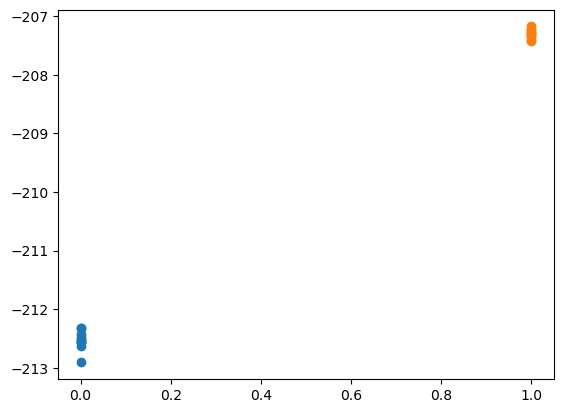

In [193]:
plt.scatter(0, np.mean(log_ratio_0_BARs), c='C0')
plt.scatter(0 * np.ones(len(log_err_0_BARs)), log_ratio_0_BARs)
plt.scatter(1, np.mean(log_ratio_1_BARs), c='C1')
plt.scatter(1 * np.ones(len(log_err_1_BARs)), log_ratio_1_BARs)

np.exp(np.array(log_ratio_0_BARs)- np.array(log_ratio_1_BARs))

### 3.1.2 - AbFlowMC flows

In [249]:
# to_return_abflow_flow_isomer_0 = {}
# to_return_abflow_flow_isomer_1 = {}

In [250]:
flow_train_slice = 0

seed = 42
seed = 0
torch.manual_seed(seed)

isomer_id = 0
md_training_size = 4000

process_id_mlp = 30019623 ## adaptive with 4000 initial MD samples ISO 0
# process_id_mlp = 30019627 ## adaptive with 4000 initial MD samples ISO 1
mlp_model = load_mlp_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[0]
flow_model = load_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[flow_train_slice]

mixture = False
update_weights = False
temperature = 350
energy_type = 'mlp'

n_chains = 200

init = flow_model_md.sample(n_chains)
init = torch.cat([init, mlp_model(init), torch.zeros((n_chains, 1)) + isomer_id], dim=1)
n_steps = 10000

to_return = run_metropolis(flow_model, init, n_chains, n_steps, energy_type,
                    temperature,
                    mixture,
                    mlp_models=[mlp_model],
                    frac_computed=0.2,
                    dim=12,
                    update_weights=update_weights,
                    scheduler_weights=10,
                    alpha=0.5,
                    return_ratios=True,
                    return_proposals=True,
                    with_tqdm=True,
                    device='cpu',
                    folder_name=None,
                 )

to_return_abflow_flow_isomer_0[flow_train_slice] = to_return


Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Use Neural Predictor: True
Mixture Model: False


Step 9999 	 Acceptance Rate 0.190: 100%|██████████| 10000/10000 [01:19<00:00, 125.05it/s]


In [251]:
mc_samples = to_return_abflow_flow_isomer_0[flow_train_slice]['xs']
prop = flow_model
target_u = mlp_model

n_trial = 10
n_chains = mc_samples.shape[1]
n_chain_per_trial = n_chains // n_trial
print('Total number of chains per trial = {:d} and samples per trial = {:d}'.format(n_chain_per_trial, n_chain_per_trial * mc_samples.shape[0]))
log_ratio_0_BARs = []
log_err_0_BARs = []

for trial in range(n_trial):
    mc_samples_t = mc_samples[:, trial*n_chain_per_trial:(trial+1)*n_chain_per_trial].reshape(-1, mc_samples.shape[-1])
    prop_samples_t = prop.sample(mc_samples_t.shape[0])
    logprob_prop = - prop.nll(prop_samples_t).detach().numpy() 
    logprob_mc = - prop.nll(mc_samples_t).detach().numpy() 
    logtgt_prop = - beta * target_u(prop_samples_t).detach().numpy()
    logtgt_mc = - beta * target_u(mc_samples_t).detach().numpy()


    logr, logr_err = compute_BAR_from_samples(logprob_prop, logprob_mc, logtgt_prop, logtgt_mc, 
                                maxiter=2000, rtol=1e-13, xtol=1e-13, ess=1)
    log_ratio_0_BARs.append(logr)
    log_err_0_BARs.append(logr_err)

    dic_results_all['kind'].append('AbFlowMM')
    dic_results_all['isomer_id'].append(isomer_id)
    dic_results_all['md_training_size'].append(md_training_size)
    dic_results_all['process_id_flow'].append(process_id_flow)
    dic_results_all['flow_train_slice'].append(flow_train_slice)
    dic_results_all['mc seed'].append(seed)
    dic_results_all['log_r'].append(logr)
    dic_results_all['trial'].append(trial)


Total number of chains per trial = 20 and samples per trial = 200000


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -3.734594088200538e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -3.051756465310973e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -3.276797770013218e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 3.2958616316136613e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -1.0579815636901913e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou

In [252]:
flow_train_slice = 0

seed = 42
seed = 0
torch.manual_seed(seed)

isomer_id = 1
md_training_size = 4000

# process_id_mlp = 30019623 ## adaptive with 4000 initial MD samples ISO 0
process_id_mlp = 30019627 ## adaptive with 4000 initial MD samples ISO 1
mlp_model = load_mlp_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[0]
flow_model = load_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[flow_train_slice]

mixture = False
update_weights = False
temperature = 350
energy_type = 'mlp'

n_chains = 200

init = flow_model_md.sample(n_chains)
init = torch.cat([init, mlp_model(init), torch.zeros((n_chains, 1)) + isomer_id], dim=1)
n_steps = 10000

to_return = run_metropolis(flow_model, init, n_chains, n_steps, energy_type,
                    temperature,
                    mixture,
                    mlp_models=[mlp_model],
                    frac_computed=0.2,
                    dim=12,
                    update_weights=update_weights,
                    scheduler_weights=10,
                    alpha=0.5,
                    return_ratios=True,
                    return_proposals=True,
                    with_tqdm=True,
                    device='cpu',
                    folder_name=None,
                 )

to_return_abflow_flow_isomer_1[flow_train_slice] = to_return


Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Use Neural Predictor: True
Mixture Model: False


Step 9999 	 Acceptance Rate 0.350: 100%|██████████| 10000/10000 [01:20<00:00, 124.04it/s]


In [253]:
mc_samples = to_return_abflow_flow_isomer_1[flow_train_slice]['xs']
prop = flow_model
target_u = mlp_model

n_trial = 10
n_chains = mc_samples.shape[1]
n_chain_per_trial = n_chains // n_trial
print('Total number of chains per trial = {:d} and samples per trial = {:d}'.format(n_chain_per_trial, n_chain_per_trial * mc_samples.shape[0]))
log_ratio_1_BARs = []
log_err_1_BARs = []

for trial in range(n_trial):
    mc_samples_t = mc_samples[:, trial*n_chain_per_trial:(trial+1)*n_chain_per_trial].reshape(-1, mc_samples.shape[-1])
    prop_samples_t = prop.sample(mc_samples_t.shape[0])
    logprob_prop = - prop.nll(prop_samples_t).detach().numpy() 
    logprob_mc = - prop.nll(mc_samples_t).detach().numpy() 
    logtgt_prop = - beta * target_u(prop_samples_t).detach().numpy()
    logtgt_mc = - beta * target_u(mc_samples_t).detach().numpy()


    logr, logr_err = compute_BAR_from_samples(logprob_prop, logprob_mc, logtgt_prop, logtgt_mc, 
                                maxiter=2000, rtol=1e-13, xtol=1e-13, ess=1)
    log_ratio_1_BARs.append(logr)
    log_err_1_BARs.append(logr_err)

    dic_results_all['kind'].append('AbFlowMM')
    dic_results_all['isomer_id'].append(isomer_id)
    dic_results_all['md_training_size'].append(md_training_size)
    dic_results_all['process_id_flow'].append(process_id_flow)
    dic_results_all['flow_train_slice'].append(flow_train_slice)
    dic_results_all['mc seed'].append(seed)
    dic_results_all['log_r'].append(logr)
    dic_results_all['trial'].append(trial)



Total number of chains per trial = 20 and samples per trial = 200000


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -9.20969910112035e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -1.9140110794069187e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 1.1856887454086973e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 6.324223420506314e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -5.463610364131455e-08 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/a

array([0.00985862, 0.00497796, 0.00507602, 0.00940107, 0.00650915,
       0.00720697, 0.00513924, 0.01483733, 0.0080894 , 0.01203729])

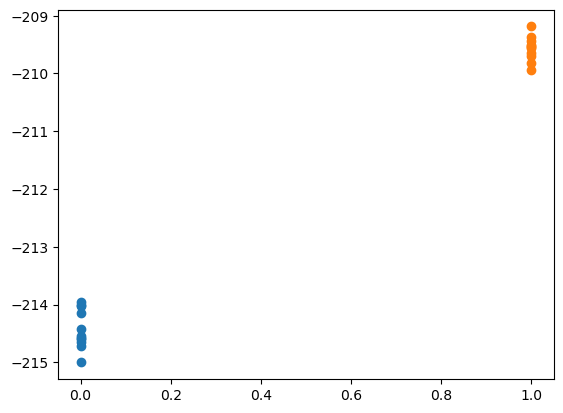

In [203]:
plt.scatter(0, np.mean(log_ratio_0_BARs), c='C0')
plt.scatter(0 * np.ones(len(log_err_0_BARs)), log_ratio_0_BARs)
plt.scatter(1, np.mean(log_ratio_1_BARs), c='C1')
plt.scatter(1 * np.ones(len(log_err_1_BARs)), log_ratio_1_BARs)

np.exp(np.array(log_ratio_0_BARs)- np.array(log_ratio_1_BARs))

#### 3.1.2.2 Flow training slice 10

In [206]:
flow_train_slice = 10

seed = 42
seed = 0
torch.manual_seed(seed)

isomer_id = 0
md_training_size = 4000

process_id_mlp = 30019623 ## adaptive with 4000 initial MD samples ISO 0
# process_id_mlp = 30019627 ## adaptive with 4000 initial MD samples ISO 1
mlp_model = load_mlp_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[0]
flow_model = load_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[flow_train_slice]

mixture = False
update_weights = False
temperature = 350
energy_type = 'mlp'

n_chains = 200

init = flow_model_md.sample(n_chains)
init = torch.cat([init, mlp_model(init), torch.zeros((n_chains, 1)) + isomer_id], dim=1)
n_steps = 10000

to_return = run_metropolis(flow_model, init, n_chains, n_steps, energy_type,
                    temperature,
                    mixture,
                    mlp_models=[mlp_model],
                    frac_computed=0.2,
                    dim=12,
                    update_weights=update_weights,
                    scheduler_weights=10,
                    alpha=0.5,
                    return_ratios=True,
                    return_proposals=True,
                    with_tqdm=True,
                    device='cpu',
                    folder_name=None,
                 )

to_return_abflow_flow_isomer_0[flow_train_slice] = to_return


Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Use Neural Predictor: True
Mixture Model: False


Step 9999 	 Acceptance Rate 0.235: 100%|██████████| 10000/10000 [01:17<00:00, 129.18it/s]


In [207]:
mc_samples = to_return_abflow_flow_isomer_0[flow_train_slice]['xs']
prop = flow_model
target_u = mlp_model

n_trial = 10
n_chains = mc_samples.shape[1]
n_chain_per_trial = n_chains // n_trial
print('Total number of chains per trial = {:d} and samples per trial = {:d}'.format(n_chain_per_trial, n_chain_per_trial * mc_samples.shape[0]))
log_ratio_0_BARs = []
log_err_0_BARs = []

for trial in range(n_trial):
    mc_samples_t = mc_samples[:, trial*n_chain_per_trial:(trial+1)*n_chain_per_trial].reshape(-1, mc_samples.shape[-1])
    prop_samples_t = prop.sample(mc_samples_t.shape[0])
    logprob_prop = - prop.nll(prop_samples_t).detach().numpy() 
    logprob_mc = - prop.nll(mc_samples_t).detach().numpy() 
    logtgt_prop = - beta * target_u(prop_samples_t).detach().numpy()
    logtgt_mc = - beta * target_u(mc_samples_t).detach().numpy()


    logr, logr_err = compute_BAR_from_samples(logprob_prop, logprob_mc, logtgt_prop, logtgt_mc, 
                                maxiter=2000, rtol=1e-13, xtol=1e-13, ess=1)
    log_ratio_0_BARs.append(logr)
    log_err_0_BARs.append(logr_err)

    dic_results_all['kind'].append('AbFlowMM')
    dic_results_all['isomer_id'].append(isomer_id)
    dic_results_all['md_training_size'].append(md_training_size)
    dic_results_all['process_id_flow'].append(process_id_flow)
    dic_results_all['flow_train_slice'].append(flow_train_slice)
    dic_results_all['mc seed'].append(seed)
    dic_results_all['log_r'].append(logr)
    dic_results_all['trial'].append(trial)


Total number of chains per trial = 20 and samples per trial = 200000


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -2.5204953715274314e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 1.9066644938448007e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 7.617337729470819e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -6.676465062582793e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 9.439617372208886e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/a

In [208]:
flow_train_slice = 10

seed = 42
seed = 0
torch.manual_seed(seed)

isomer_id = 1
md_training_size = 4000

# process_id_mlp = 30019623 ## adaptive with 4000 initial MD samples ISO 0
process_id_mlp = 30019627 ## adaptive with 4000 initial MD samples ISO 1
mlp_model = load_mlp_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[0]
flow_model = load_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[flow_train_slice]

mixture = False
update_weights = False
temperature = 350
energy_type = 'mlp'

n_chains = 200

init = flow_model_md.sample(n_chains)
init = torch.cat([init, mlp_model(init), torch.zeros((n_chains, 1)) + isomer_id], dim=1)
n_steps = 10000

to_return = run_metropolis(flow_model, init, n_chains, n_steps, energy_type,
                    temperature,
                    mixture,
                    mlp_models=[mlp_model],
                    frac_computed=0.2,
                    dim=12,
                    update_weights=update_weights,
                    scheduler_weights=10,
                    alpha=0.5,
                    return_ratios=True,
                    return_proposals=True,
                    with_tqdm=True,
                    device='cpu',
                    folder_name=None,
                 )

to_return_abflow_flow_isomer_1[flow_train_slice] = to_return


Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Use Neural Predictor: True
Mixture Model: False


Step 9999 	 Acceptance Rate 0.310: 100%|██████████| 10000/10000 [01:17<00:00, 129.31it/s]


In [209]:
mc_samples = to_return_abflow_flow_isomer_1[flow_train_slice]['xs']
prop = flow_model
target_u = mlp_model

n_trial = 10
n_chains = mc_samples.shape[1]
n_chain_per_trial = n_chains // n_trial
print('Total number of chains per trial = {:d} and samples per trial = {:d}'.format(n_chain_per_trial, n_chain_per_trial * mc_samples.shape[0]))
log_ratio_1_BARs = []
log_err_1_BARs = []

for trial in range(n_trial):
    mc_samples_t = mc_samples[:, trial*n_chain_per_trial:(trial+1)*n_chain_per_trial].reshape(-1, mc_samples.shape[-1])
    prop_samples_t = prop.sample(mc_samples_t.shape[0])
    logprob_prop = - prop.nll(prop_samples_t).detach().numpy() 
    logprob_mc = - prop.nll(mc_samples_t).detach().numpy() 
    logtgt_prop = - beta * target_u(prop_samples_t).detach().numpy()
    logtgt_mc = - beta * target_u(mc_samples_t).detach().numpy()


    logr, logr_err = compute_BAR_from_samples(logprob_prop, logprob_mc, logtgt_prop, logtgt_mc, 
                                maxiter=2000, rtol=1e-13, xtol=1e-13, ess=1)
    log_ratio_1_BARs.append(logr)
    log_err_1_BARs.append(logr_err)

    dic_results_all['kind'].append('AbFlowMM')
    dic_results_all['isomer_id'].append(isomer_id)
    dic_results_all['md_training_size'].append(md_training_size)
    dic_results_all['process_id_flow'].append(process_id_flow)
    dic_results_all['flow_train_slice'].append(flow_train_slice)
    dic_results_all['mc seed'].append(seed)
    dic_results_all['log_r'].append(logr)
    dic_results_all['trial'].append(trial)


Total number of chains per trial = 20 and samples per trial = 200000


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 1.641064727664343e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -1.0589900227842008e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 1.6712616002223513e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -1.0588534848920972e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 3.5829195610403985e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou

array([0.00378317, 0.00406613, 0.00310225, 0.00337917, 0.00400396,
       0.00332852, 0.00350355, 0.00391103, 0.00382356, 0.00433757])

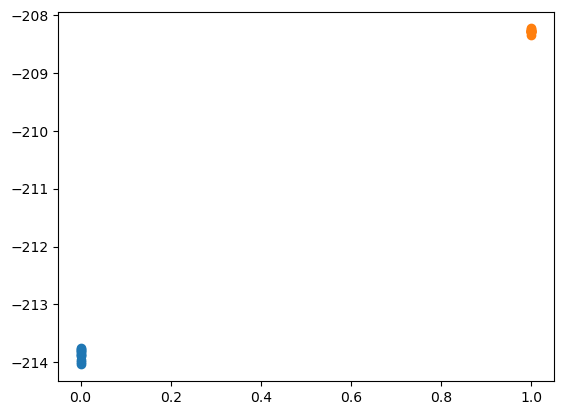

In [210]:
plt.scatter(0, np.mean(log_ratio_0_BARs), c='C0')
plt.scatter(0 * np.ones(len(log_err_0_BARs)), log_ratio_0_BARs)
plt.scatter(1, np.mean(log_ratio_1_BARs), c='C1')
plt.scatter(1 * np.ones(len(log_err_1_BARs)), log_ratio_1_BARs)

np.exp(np.array(log_ratio_0_BARs)- np.array(log_ratio_1_BARs))

# SAVING THE DATA

In [274]:
import datetime
today = datetime.date.today()
import pickle

In [275]:
dic_mcmcs = {
    'md_0': to_return_md_flow_isomer_0,
    'abflow_0': to_return_abflow_flow_isomer_0,
    'md_1': to_return_md_flow_isomer_1,
    'abflow_1': to_return_abflow_flow_isomer_1
}
with open(subproject_path + '/'+str(today)+'-MCMC-outputs.pkl', 'wb') as f:
    pickle.dump(dic_mcmcs, f)

In [264]:
df = pd.DataFrame(dic_results_all)
df.to_csv(subproject_path + '/'+str(today)+'-BAR-results.csv', index=False)

In [265]:
df

,kind,isomer_id,md_training_size,process_id_flow,mc seed,flow_train_slice,log_r,trial
0,MD,0,4000,30064793,0,-1,-212.623789,0
1,MD,0,4000,30064793,0,-1,-212.911108,1
2,MD,0,4000,30064793,0,-1,-212.508432,2
3,MD,0,4000,30064793,0,-1,-212.425972,3
4,MD,0,4000,30064793,0,-1,-212.562206,4
...,...,...,...,...,...,...,...,...
75,AbFlowMM,1,4000,30064797,0,0,-208.197240,5
76,AbFlowMM,1,4000,30064797,0,0,-208.120048,6
77,AbFlowMM,1,4000,30064797,0,0,-208.178103,7
78,AbFlowMM,1,4000,30064797,0,0,-208.182435,8


{'whiskers': [<matplotlib.lines.Line2D at 0x2a55a6f10>,
 'caps': [<matplotlib.lines.Line2D at 0x2a55d4690>,
 'boxes': [<matplotlib.lines.Line2D at 0x2a55a62d0>,
 'medians': [<matplotlib.lines.Line2D at 0x2a55d5bd0>,
 'fliers': [<matplotlib.lines.Line2D at 0x2a55d6690>,
 'means': []}

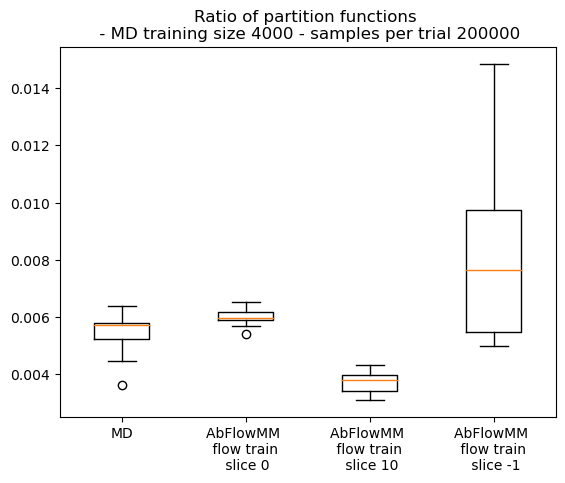

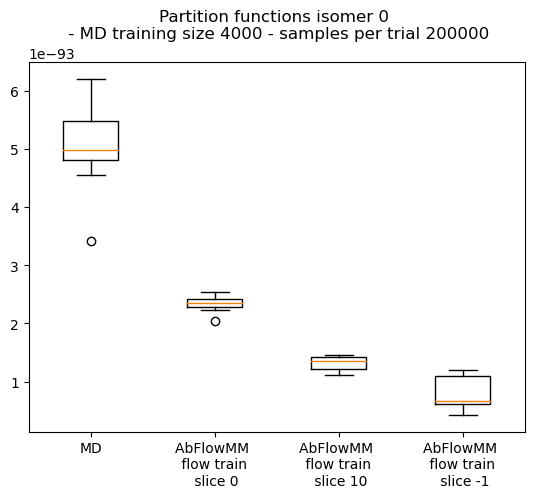

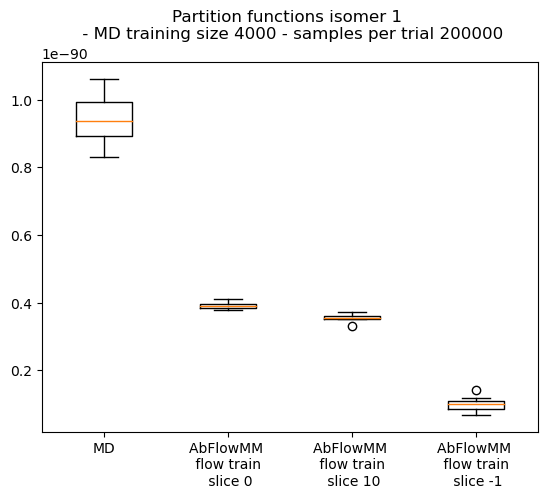

In [270]:
# plot boxplots of ratio of partition functions

df = pd.read_csv(subproject_path + '/'+str(today)+'-BAR-results.csv')

zrs = []
z0s = []
z1s = []
labels = []

# MD results
labels.append('MD')
df_md = df.loc[df['kind'] == 'MD']
df_md_0 = df_md.loc[df_md['isomer_id'] == 0]
df_md_1 = df_md.loc[df_md['isomer_id'] == 1]

log_r_0 = df_md_0['log_r'].values
log_r_1 = df_md_1['log_r'].values

z_r_md = np.exp(log_r_0 - log_r_1)
zrs.append(z_r_md)

z_0_md = np.exp(log_r_0)
z_1_md = np.exp(log_r_1)
z0s.append(z_0_md)
z1s.append(z_1_md)

# AbFlowMM results - flow training slice -1
for train_slice in [0,10,-1]:
    labels.append('AbFlowMM \n flow train \n slice {:d}'.format(train_slice))
    df_abflow = df.loc[df['kind'] == 'AbFlowMM']
    df_abflow_0 = df_abflow.loc[(df_abflow['isomer_id'] == 0) & (df_abflow['flow_train_slice'] == train_slice)]
    df_abflow_1 = df_abflow.loc[(df_abflow['isomer_id'] == 1) & (df_abflow['flow_train_slice'] == train_slice)]

    log_r_0 = df_abflow_0['log_r'].values
    log_r_1 = df_abflow_1['log_r'].values

    z_r = np.exp(log_r_0 - log_r_1)
    zrs.append(z_r)

    z_0 = np.exp(log_r_0)
    z_1 = np.exp(log_r_1)
    z0s.append(z_0)
    z1s.append(z_1)



plt.figure()
plt.title('Ratio of partition functions \n - MD training size {:d} - samples per trial {:d}'.format(md_training_size, n_chain_per_trial*n_steps))
plt.boxplot(zrs, labels=labels)

plt.figure()
plt.title('Partition functions isomer 0 \n - MD training size {:d} - samples per trial {:d}'.format(md_training_size, n_chain_per_trial*n_steps))
plt.boxplot(z0s, labels=labels)

plt.figure()
plt.title('Partition functions isomer 1 \n - MD training size {:d} - samples per trial {:d}'.format(md_training_size, n_chain_per_trial*n_steps))
plt.boxplot(z1s, labels=labels)


In [263]:
(df_abflow['flow_train_slice'] == train_slice)

20    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
30    False
31    False
32    False
33    False
34    False
35    False
36    False
37    False
38    False
39    False
40    False
41    False
42    False
43    False
44    False
45    False
46    False
47    False
48    False
49    False
50    False
51    False
52    False
53    False
54    False
55    False
56    False
57    False
58    False
59    False
Name: flow_train_slice, dtype: bool